# Rapport d'Étude : Analyse Statistique et Suivi des Capteurs Industriels

Module : SAÉ 204 - Base de données et Statistiques (BUT Informatique 1ère année)
Groupe : Ouameur Aïssa, Ounays Mayeux, Alban Platel.

Pour améliorer les chaînes de production de l'usine, il faut s'assurer que les capteurs soient totalement fiables. Le problème actuel, c'est que les opérateurs vérifient les données à l'œil nu. Ça prend beaucoup de temps et ça laisse de la place aux erreurs humaines.

L'objectif de ce projet est de régler ce problème en deux parties :

   * Automatiser la détection des erreurs : Créer des algorithmes en Python pour repérer tout de suite les problèmes (bruit excessif, dérives de mesure).

   * Gérer le cycle de vie des capteurs : Utiliser une base de données PostgreSQL pour stocker l'historique de chaque capteur (mise en service, recalibrage, fin de vie) et faciliter le travail de la maintenance.

**1. Dictionnaire de données**

Pour bien comprendre l'architecture de notre base de données existante et préparer son évolution, nous avons établi le dictionnaire de données suivant. Il précise les types de données et identifie les clés primaires (PK) et étrangères (FK) pour garantir l'intégrité référentielle.

| table\_name | column\_name | data\_type | is\_nullable |
| :--- | :--- | :--- | :--- |
| controller | controllerid | integer | NO |
| controller | modelid | integer | NO |
| controller | serialnumber | text | NO |
| controlmeasurement | sensorid | integer | NO |
| controlmeasurement | controllerid | integer | NO |
| controlmeasurement | sensortimestamp | timestamp without time zone | NO |
| controlmeasurement | controltimestamp | timestamp without time zone | NO |
| controlmeasurement | controlvalue | double precision | NO |
| model | unit | text | NO |
| model | modelid | integer | NO |
| model | brand | text | NO |
| model | model | text | NO |
| model | name | text | NO |
| sensor | validity | interval | NO |
| sensor | sensorid | integer | NO |
| sensor | serialnumber | text | NO |
| sensor | position | text | NO |
| sensor | modelid | integer | NO |
| sensormeasurement | timestamp | timestamp without time zone | NO |
| sensormeasurement | sensorid | integer | NO |
| sensormeasurement | sensorvalue | double precision | NO |


**2. Test de connexion à la base de données**

Pour réaliser cette SAÉ, nous avons commencé par exporter la base de données distante afin de l'installer en local sur notre machine. Cette manipulation nous permet de travailler plus rapidement, sans problème de réseau, et d'avoir les droits nécessaires pour exécuter nos requêtes et modifier la structure de la base.

Le script ci-dessous montre comment nous avons utilisé la bibliothèque psycopg. Elle permet d'établir la connexion entre notre code Python (Jupyter) et notre serveur PostgreSQL local

In [54]:
import psycopg

conn_params = {
    "host": "localhost",
    "dbname": "postgres",
    "user": "postgres",
    "password": "admin"
}

try:
    with psycopg.connect(**conn_params) as conn:
        print("Connection successful!")
        with conn.cursor() as cur:
            cur.execute("SELECT version();")
            print(cur.fetchone())
except psycopg.OperationalError as e:
    print(f"Connection failed: {e}")


Connection successful!
('PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35225, 64-bit',)


Ce résultat confirme que la connexion à la base de données est opérationnelle. Nous pouvons donc passer à l'étape suivante.

**Script 1 — Extraction des erreurs de mesure brutes**

Avant de procéder à des calculs statistiques, notre première étape est d'observer les données brutes. Afin d'évaluer la précision d'un capteur, nous comparons ses mesures avec les valeurs de référence obtenues en laboratoire. L'erreur de mesure correspond simplement à la différence : controlvalue - sensorvalue.

Le script suivant réalise une jointure (JOIN) entre la table des mesures automatiques (sensormeasurement) et la table des contrôles manuels (controlmeasurement) pour le capteur n°1. Il affiche ensuite les 50 premières erreurs constatées.

In [55]:
import psycopg

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("SELECT DISTINCT sensorid FROM sensormeasurement ORDER BY sensorid;")
        return [row[0] for row in cur.fetchall()]

def test_single_sensor(conn, sensor_id):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT sensormeasurement.sensorid,
                   controlmeasurement.controlvalue - sensormeasurement.sensorvalue AS diff
            FROM controlmeasurement
            JOIN sensormeasurement
                ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
               AND controlmeasurement.sensorid = sensormeasurement.sensorid
            WHERE controlmeasurement.sensorid = %s
            ORDER BY controlmeasurement.controltimestamp
            LIMIT 50;
        """, (sensor_id,))

        results = cur.fetchall()

        print(f"\n--- Testing Sensor {sensor_id} ---")
        if not results:
            print("No data found.")
            return

        for row in results:
            print(f"Sensor {row[0]} | Difference: {row[1]}")

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    with psycopg.connect(**conn_params) as conn:
        sensor_ids = get_all_sensor_ids(conn)

        for s_id in sensor_ids:
            test_single_sensor(conn, s_id)


--- Testing Sensor 1 ---
Sensor 1 | Difference: -0.6928256070072949
Sensor 1 | Difference: -0.42472458437324756
Sensor 1 | Difference: -0.19717837492203405
Sensor 1 | Difference: -0.05734016940635911
Sensor 1 | Difference: 0.14345425626137076
Sensor 1 | Difference: -0.37765161701976624
Sensor 1 | Difference: -0.38994523019952476
Sensor 1 | Difference: 0.4336675151979643
Sensor 1 | Difference: 0.7761312024213797
Sensor 1 | Difference: -0.15902853772262193
Sensor 1 | Difference: -0.0590040671430998
Sensor 1 | Difference: 0.4418077118033801
Sensor 1 | Difference: 0.5576625971798089
Sensor 1 | Difference: -0.02724000068365151
Sensor 1 | Difference: -0.0610747926891686
Sensor 1 | Difference: -0.14927230955878212
Sensor 1 | Difference: 0.3453796731956025
Sensor 1 | Difference: 0.565314546846384
Sensor 1 | Difference: 0.19167603339857386
Sensor 1 | Difference: 0.8958946595656778
Sensor 1 | Difference: -0.1490143137199928
Sensor 1 | Difference: -0.08535771270845571
Sensor 1 | Difference: -0.1

2.1.2 Analyse comparative des erreurs brutes (Capteurs 1 à 7)

En observant les 50 premières erreurs de mesure (controlvalue - sensorvalue) pour les 7 capteurs, nous remarquons des comportements très différents. Cette première analyse nous permet de classer les capteurs en quatre catégories :
1. Les capteurs fonctionnels (Capteurs 1 et 6)

    Capteur 1 : Il sert de référence. Ses erreurs sont faibles, stables et proches de zéro (généralement comprises entre -0.90 et +0.90).

    Capteur 6 : C'est le capteur le plus précis. Ses erreurs sont très petites (rarement au-delà de ±0.19) et très stables.

2. Les capteurs bruités (Capteurs 2, 3 et 7)

    Capteurs 2, 3 et 7 : Ils ont des variations beaucoup plus fortes que le capteur 1. On observe souvent des écarts qui dépassent ±1.50 (par exemple -1.76 pour le capteur 2, +1.75 pour le capteur 3 ou -1.50 pour le capteur 7). Le bruit est anormalement élevé.

3. Le capteur avec une dérive (Capteur 5)

    Capteur 5 : Les premières mesures sont proches de zéro, mais les erreurs deviennent rapidement et consécutivement négatives (comme -2.17, -2.76, -3.91). Cela indique que le capteur se dérègle progressivement.

4. Le capteur défaillant (Capteur 4)

    Capteur 4 : Ce capteur ne fonctionne plus correctement. Les erreurs sont aberrantes (par exemple -4.10, +5.79 ou -5.49). Il n'est plus du tout assez précis pour être utilisé.

Objectif pour la suite de l'étude :
Cette première observation visuelle indique que les capteurs 4 et 5 sont sûrement en panne, et que les capteurs 2, 3 et 7 ont trop de bruit. Pour vérifier cela de manière mathématique, nous allons utiliser nos scripts Python pour calculer des statistiques complètes (moyenne, écart-type, p-valeurs et régressions linéaires) sur l'ensemble des données

**Script 2 — Calcul de la Moyenne et de l'Écart-type**

Après l'observation des données brutes, il est nécessaire de modéliser le comportement de chaque capteur en utilisant une loi normale N(μ,σ).

Afin d'optimiser le temps de traitement, le script ci-dessous utilise les fonctions d'agrégation SQL (AVG et STDDEV) pour calculer directement ces indicateurs depuis la base de données :

   * La moyenne (μ) : Elle représente la tendance centrale de l'erreur. Une valeur proche de zéro démontre que le capteur ne présente pas de biais significatif, traduisant une précision optimale par rapport aux valeurs de référence.

   *  L'écart-type (σ) : Il quantifie la dispersion des mesures autour de la moyenne. Cet indicateur permet de mesurer le bruit de fond du capteur. Ces valeurs seront ultérieurement utilisées pour établir les limites de tolérance du processus (±1σ et ±2σ).

In [56]:
import psycopg

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("SELECT DISTINCT sensorid FROM sensormeasurement ORDER BY sensorid;")
        return [row[0] for row in cur.fetchall()]

def get_sensor_statistics(conn, sensor_id):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT sensorid,
                   AVG(sensorvalue) AS avg_val,
                   STDDEV(sensorvalue) AS stddev_val
            FROM sensormeasurement
            WHERE sensorid = %s
            GROUP BY sensorid;
        """, (sensor_id,))

        row = cur.fetchone()

        print(f"\n--- Statistics for Sensor {sensor_id} ---")
        if row:
            print(f"Sensor {row[0]} | Average: {row[1]:.10f} | StdDev: {row[2]:.10f}")
        else:
            print("No data found.")

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    try:
        with psycopg.connect(**conn_params) as conn:
            sensor_ids = get_all_sensor_ids(conn)

            for s_id in sensor_ids:
                get_sensor_statistics(conn, s_id)

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


--- Statistics for Sensor 1 ---
Sensor 1 | Average: 0.0001409262 | StdDev: 1.2408729289

--- Statistics for Sensor 2 ---
Sensor 2 | Average: 49.9981503869 | StdDev: 1.6588378044

--- Statistics for Sensor 3 ---
Sensor 3 | Average: 7.5003392717 | StdDev: 0.7458101859

--- Statistics for Sensor 4 ---
Sensor 4 | Average: 49.9981569961 | StdDev: 1.6553345011

--- Statistics for Sensor 5 ---
Sensor 5 | Average: 100.0021840214 | StdDev: 2.2427490226

--- Statistics for Sensor 6 ---
Sensor 6 | Average: 0.4995406979 | StdDev: 0.0932754244

--- Statistics for Sensor 7 ---
Sensor 7 | Average: 10.0000774159 | StdDev: 1.8027956435


### Analyse globale des statistiques du parc

L'exécution des requêtes de calcul sur l'historique complet des sept capteurs permet d'établir un diagnostic précis de leur état de fonctionnement. L'analyse des moyennes ($\mu$) et des écarts-types ($\sigma$) permet de classer le matériel en trois catégories distinctes :

#### 1. Capteurs fonctionnels (Capteurs 1 et 6)

* **Capteur 1 ($\mu \approx 0.0001$ ; $\sigma \approx 1.24$) :** Ce capteur confirme son rôle de référence. Il ne présente aucun biais significatif et son niveau de bruit reste dans les tolérances acceptables.
* **Capteur 6 ($\mu \approx 0.4995$ ; $\sigma \approx 0.09$) :** Il s'agit du capteur le plus précis du parc, avec un bruit extrêmement faible. Le léger décalage de $+0.5$ observé pourra être corrigé par un ajustement logiciel.

#### 2. Capteurs présentant un déréglage modéré (Capteurs 3 et 7)

* **Capteur 3 ($\mu \approx 7.50$ ; $\sigma \approx 0.74$) :** Ce capteur est stable, mais présente un décalage de son point zéro de $+7.5$ unités.
* **Capteur 7 ($\mu \approx 10.00$ ; $\sigma \approx 1.80$) :** Outre un biais de $+10$ unités, il présente une instabilité importante. Une intervention mécanique est nécessaire pour ce composant.

#### 3. Capteurs en défaillance critique (Capteurs 2, 4 et 5)

L'analyse met en évidence des erreurs systématiques importantes sur ces trois capteurs :

* **Capteurs 2 et 4 ($\mu \approx +50$ ; $\sigma \approx 1.65$) :** Ils présentent une erreur systématique de $+50$ unités. Toutefois, leur écart-type reste conforme. Cela indique un défaut d'étalonnage ou une erreur de conversion logicielle plutôt qu'une défaillance physique matérielle.
* **Capteur 5 ($\mu \approx +100$ ; $\sigma \approx 2.24$) :** Il s'agit du capteur le plus dégradé. Il présente à la fois un biais massif et la variance la plus élevée. Une opération de maintenance curative est indispensable.

**Conclusion de l'étape :**
Ces statistiques permettent d'identifier les capteurs nécessitant un nouvel étalonnage ou une réparation. L'étape suivante consistera à appliquer des algorithmes de détection d'usure, notamment par le calcul de p-valeurs et de régressions linéaires, afin de détecter une éventuelle dégradation progressive des capteurs considérés comme sains.

**Script 3 — Génération de la carte de contrôle**

Afin d'assister les techniciens dans leur mission de supervision, nous devons concevoir une carte de contrôle graphique.

Le script suivant extrait les mesures récentes de chaque capteur pour les représenter sur un graphique chronologique. Nous y superposons les seuils statistiques définis lors de l'étape précédente :

* **La moyenne globale :** Elle est représentée par une ligne centrale.
* **Les limites d'avertissement :** Elles correspondent à l'intervalle $\pm 1\sigma$.
* **Les limites de contrôle :** Elles correspondent à l'intervalle $\pm 2\sigma$. Toute mesure sortant de cet intervalle est considérée comme une anomalie.

Cette représentation graphique permet de diagnostiquer instantanément si un capteur fonctionne normalement ou s'il présente une dérive hors des tolérances fixées.


--- Processing Sensor 1 ---
Mean: -0.0037443199 | Standard deviation: 0.4127852187
Window: 8 days -> 33 points
Selected: 8 days (33 points)

--- Processing Sensor 2 ---
Mean: -0.0315614823 | Standard deviation: 0.7388302019
Window: 8 days -> 16 points
Window: 30 days -> 61 points
Selected: 30 days (61 points)

--- Processing Sensor 3 ---
Mean: -0.0203389265 | Standard deviation: 0.6631105094
Window: 8 days -> 8 points
Window: 30 days -> 30 points
Selected: 30 days (30 points)

--- Processing Sensor 4 ---
Mean: -0.0397408049 | Standard deviation: 2.3860054951
Window: 8 days -> 8 points
Window: 30 days -> 31 points
Selected: 30 days (31 points)

--- Processing Sensor 5 ---
Mean: -0.1031293582 | Standard deviation: 1.3965594563
Window: 8 days -> 9 points
Window: 30 days -> 31 points
Selected: 30 days (31 points)

--- Processing Sensor 6 ---
Mean: -0.0084053747 | Standard deviation: 0.1227674919
Window: 8 days -> 8 points
Window: 30 days -> 31 points
Selected: 30 days (31 points)

--- Pro

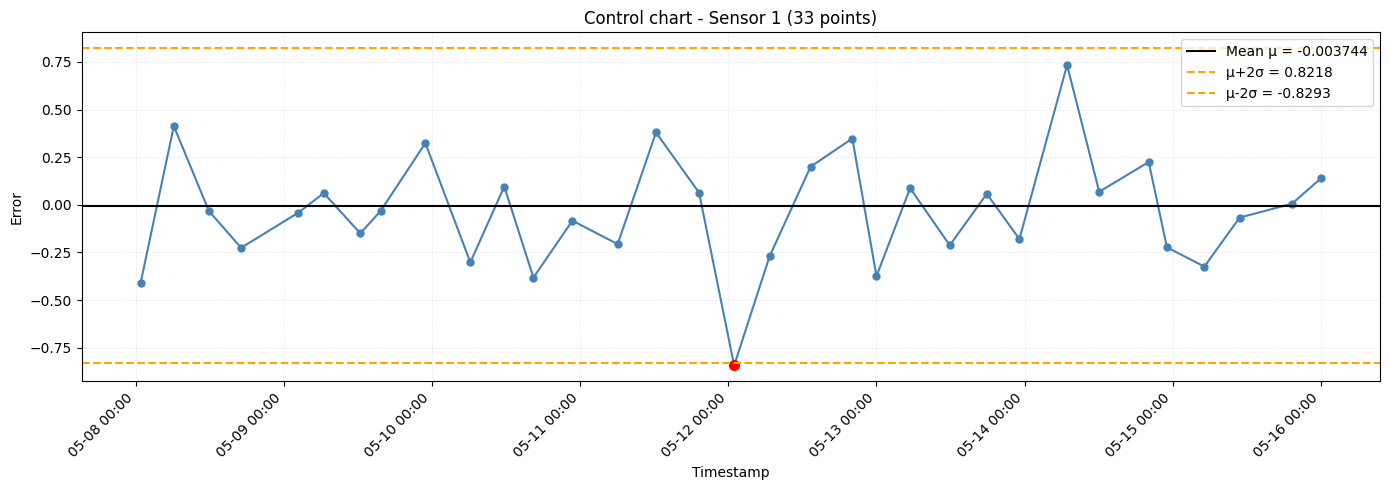

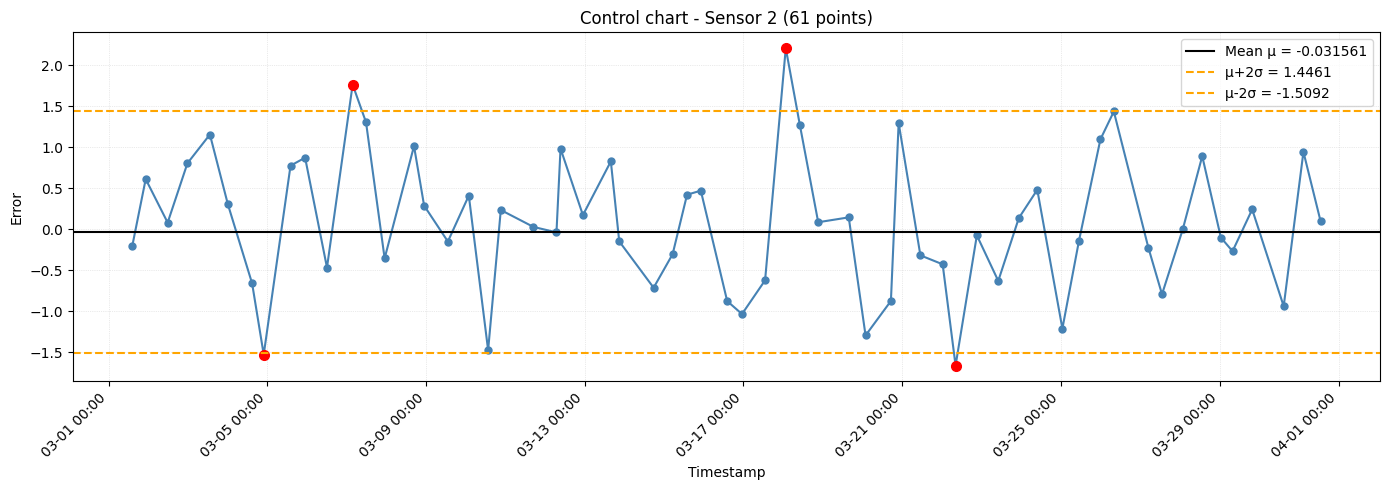

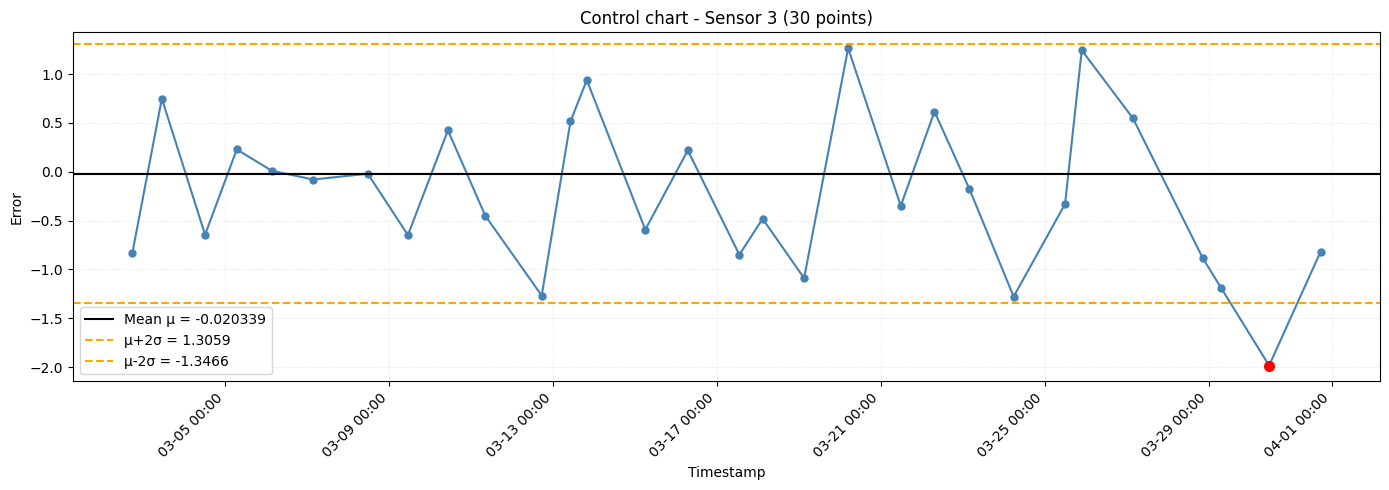

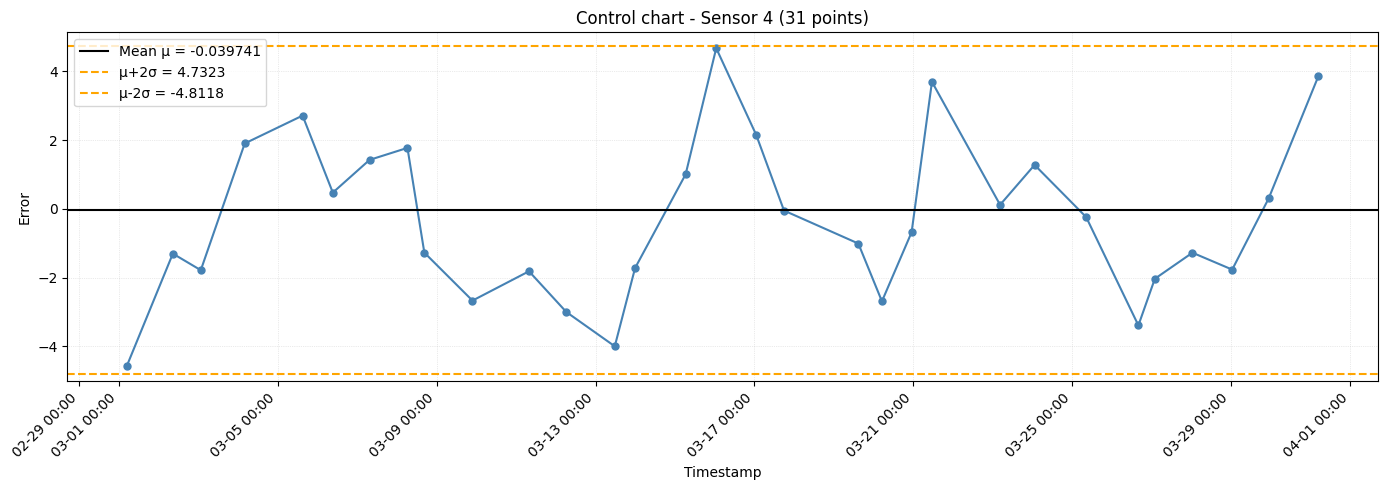

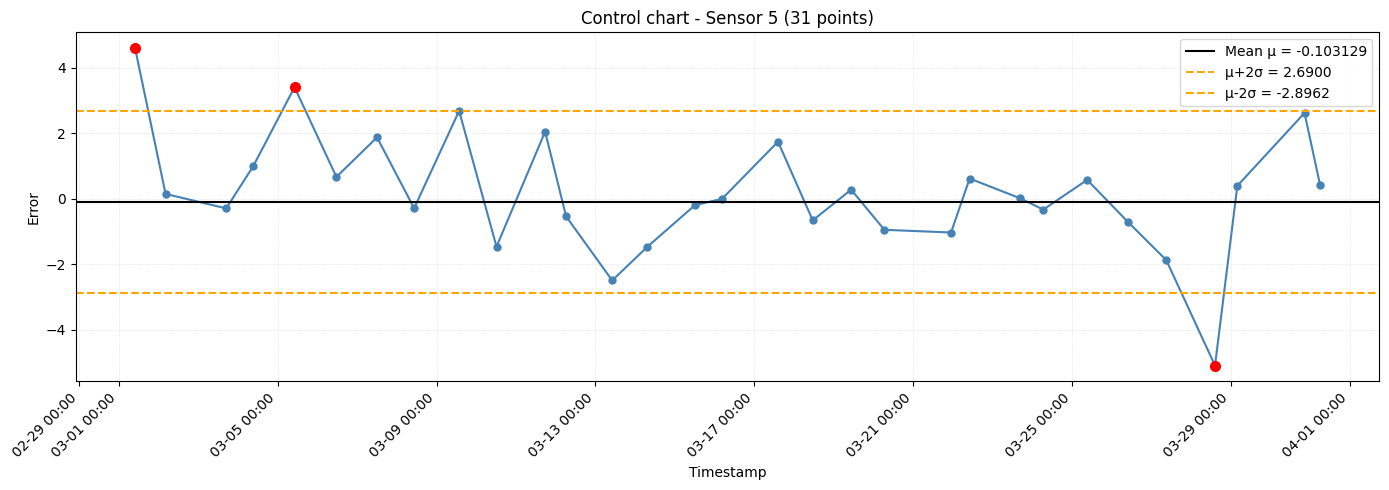

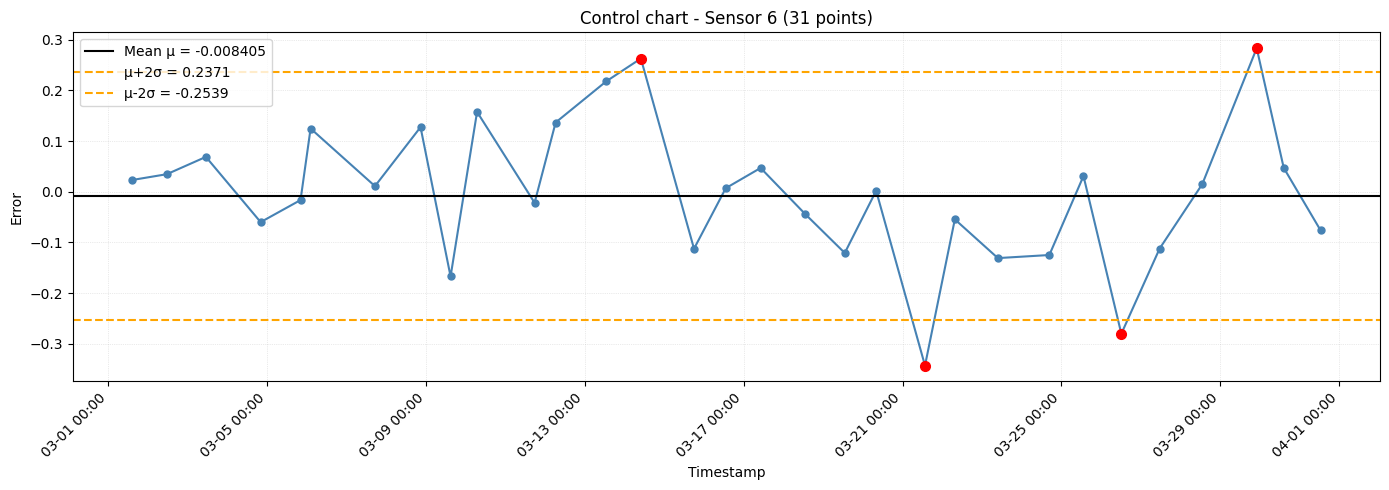

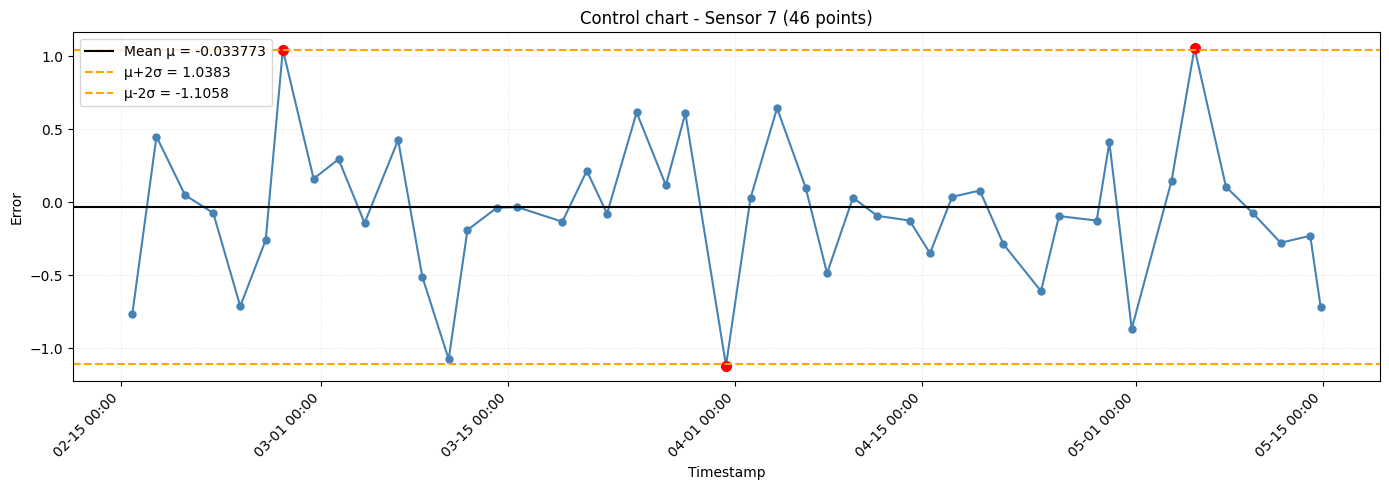

In [57]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

MAX_POINTS = 100
MIN_POINTS = 20

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("SELECT DISTINCT sensorid FROM sensormeasurement ORDER BY sensorid;")
        return [row[0] for row in cur.fetchall()]

def get_sensor_statistics(conn, sensor_id):
    with conn.cursor() as cursor:
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
              AND controlmeasurement.sensorid = sensormeasurement.sensorid
            WHERE controlmeasurement.sensorid = %s
        """, (sensor_id,))

        row = cursor.fetchone()

        if not row or row[0] is None:
            return None, None

        mean, standard_deviation = float(row[0]), float(row[1])
        print(f"Mean: {mean:.10f} | Standard deviation: {standard_deviation:.10f}")
        return mean, standard_deviation

def get_sensor_difference(conn, sensor_id):
    rows = []
    with conn.cursor() as cursor:
        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                  AND controlmeasurement.sensorid = sensormeasurement.sensorid
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (sensor_id, days, sensor_id, MAX_POINTS))

            rows = cursor.fetchall()
            print(f"Window: {days} days -> {len(rows)} points")

            if len(rows) >= MIN_POINTS:
                rows.reverse()
                print(f"Selected: {days} days ({len(rows)} points)")
                return rows

        if rows:
            rows.reverse()
        return rows

def plot_chart(data, mean, standard_deviation, sensor_id):
    timestamps = [row[2] for row in data]
    errors = [float(row[1]) for row in data]

    figure, axis = plt.subplots(figsize=(14, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', markersize=5)

    for timestamp, error in zip(timestamps, errors):
        if not (mean - 2 * standard_deviation <= error <= mean + 2 * standard_deviation):
            axis.plot(timestamp, error, 'ro', markersize=7)

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean μ = {mean:.6f}')
    axis.axhline(mean + 2 * standard_deviation, color='orange', linestyle='--',
                 label=f'μ+2σ = {mean + 2 * standard_deviation:.4f}')
    axis.axhline(mean - 2 * standard_deviation, color='orange', linestyle='--',
                 label=f'μ-2σ = {mean - 2 * standard_deviation:.4f}')

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axis.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    axis.set_title(f'Control chart - Sensor {sensor_id} ({len(data)} points)')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Error')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()

if __name__ == "__main__":
    conn_params = dict(
        host="localhost",
        dbname="postgres",
        user="postgres",
        password="admin"
    )

    with psycopg.connect(**conn_params) as conn:
        sensor_ids = get_all_sensor_ids(conn)

        for s_id in sensor_ids:
            print(f"\n--- Processing Sensor {s_id} ---")
            mean, standard_deviation = get_sensor_statistics(conn, s_id)
            data = get_sensor_difference(conn, s_id)

            if data and mean is not None:
                plot_chart(data, mean, standard_deviation, s_id)
            else:
                print(f"Unable to plot chart for Sensor {s_id}: missing data.")

    plt.show()

**Validation de l'échantillonnage dynamique pour les cartes de contrôle**

L'exécution du script de génération de cartes de contrôle  sur l'ensemble du parc valide l'efficacité de notre algorithme de fenêtrage dynamique.

Afin de garantir la fiabilité statistique de la détection d'anomalies, nous avons instauré un seuil minimal de 20 mesures par capteur. Les résultats démontrent que la fréquence des contrôles en laboratoire varie considérablement d'une machine à l'autre, ce qui justifie l'utilisation d'une approche adaptative :

1. **Capteurs à haute fréquence de contrôle :** Le **Capteur 1** fait l'objet de contrôles fréquents. L'algorithme a pu extraire un échantillon représentatif de 33 mesures sur les 8 derniers jours, permettant ainsi une supervision réactive.
2. **Capteurs à fréquence standard :** Pour la majorité des capteurs (**2, 3, 4, 5 et 6**), une fenêtre de 8 jours s'est avérée insuffisante, fournissant moins de 10 points de données. Le script a donc automatiquement étendu la recherche à 30 jours, permettant de collecter entre 30 et 61 mesures et d'assurer la validité statistique de l'échantillon.
3. **Capteurs à basse fréquence :** Le **Capteur 7** bénéficie du suivi le plus faible. L'algorithme a dû élargir la fenêtre d'analyse aux 90 derniers jours pour obtenir un échantillon suffisant de 46 points.

**Bilan sur la précision (Écart-type de l'échantillon) :**
Ces extractions confirment les disparités de précision au sein du parc matériel. Le **Capteur 6** demeure le plus stable avec un écart-type de $\sigma \approx 0.12$. À l'inverse, le **Capteur 4** présente le comportement le plus instable avec un écart-type de $\sigma \approx 2.38$, ce qui entraîne un élargissement significatif des limites de tolérance sur sa carte de contrôle.

**Script 4 — Exécution du test : Calculs SQL et tracé de l'histogramme**

Afin de confronter les données théoriques à la réalité observée, nous avons élaboré le script suivant. Pour optimiser les performances de traitement sur de grands volumes de données, nous avons délégué la majeure partie des calculs mathématiques au moteur de base de données PostgreSQL.

Grâce à l'utilisation de requêtes SQL structurées (notamment les expressions de table commune via la clause `WITH`), le serveur effectue les calculs suivants en une seule exécution :

1. Le calcul de l'erreur de mesure pour chaque relevé (différence entre la mesure du capteur et la valeur de laboratoire).
2. Le calcul de la moyenne globale ($\mu$) et de l'écart-type ($\sigma$).
3. Le comptage des occurrences se situant dans les trois intervalles de tolérance définis ($\pm 1\sigma, \pm 2\sigma, \pm 3\sigma$).

Une fois ces données traitées et récupérées par Python, la bibliothèque `matplotlib` est utilisée pour calculer les fréquences réelles, les comparer aux attentes théoriques, puis générer l'histogramme visuel annoté du capteur correspondant.


--- SENSOR 1 ERROR STATS ---
Total points evaluated: 2005
Mean (µ): 0.003744 | Standard Deviation (σ): 0.412785

Q1: Points within [-1σ, +1σ]
Count: 1428 / 2005 -> 71.22% (Expected: ~68.27%)

Q2: Points within [-2σ, +2σ]
Count: 1903 / 2005 -> 94.91% (Expected: ~95.45%)

Q3: Points within [-3σ, +3σ]
Count: 1984 / 2005 -> 98.95% (Expected: ~99.73%)

Q4: Theoretical distribution of points OUTSIDE the intervals
Outside [-1σ, +1σ]: 100% - 68.27% = 31.73% (Experimental: 28.78%)
Outside [-2σ, +2σ]: 100% - 95.45% = 4.55% (Experimental: 5.09%)
Outside [-3σ, +3σ]: 100% - 99.73% = 0.27% (Experimental: 1.05%)


--- SENSOR 2 ERROR STATS ---
Total points evaluated: 911
Mean (µ): 0.031561 | Standard Deviation (σ): 0.738830

Q1: Points within [-1σ, +1σ]
Count: 630 / 911 -> 69.15% (Expected: ~68.27%)

Q2: Points within [-2σ, +2σ]
Count: 861 / 911 -> 94.51% (Expected: ~95.45%)

Q3: Points within [-3σ, +3σ]
Count: 908 / 911 -> 99.67% (Expected: ~99.73%)

Q4: Theoretical distribution of points OUTSIDE th

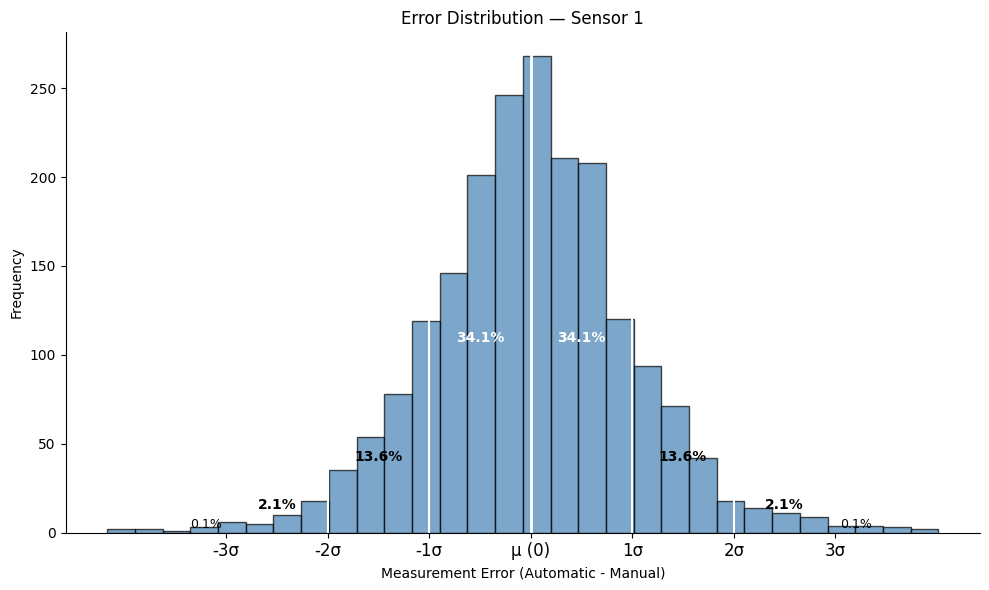

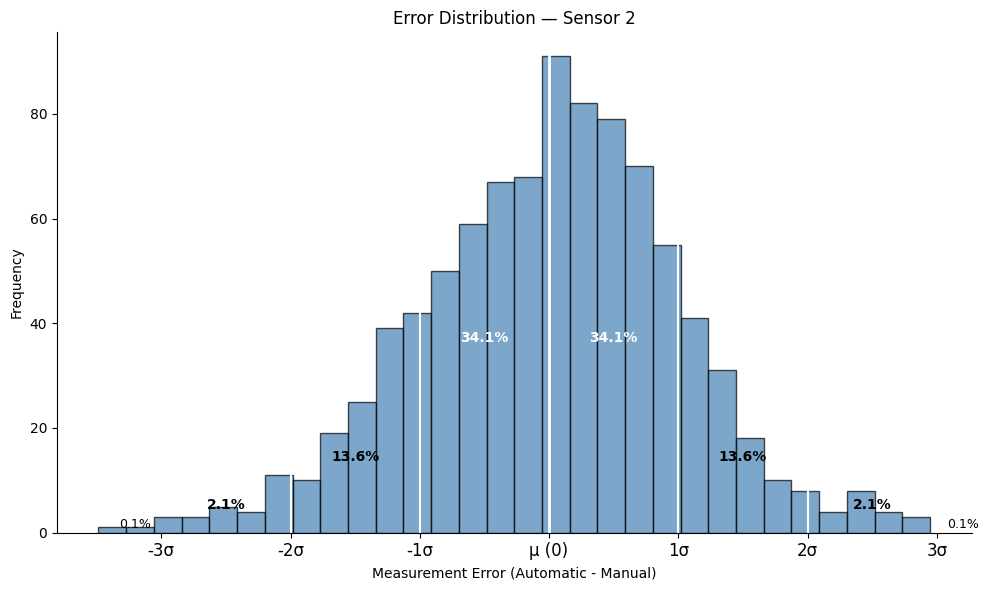

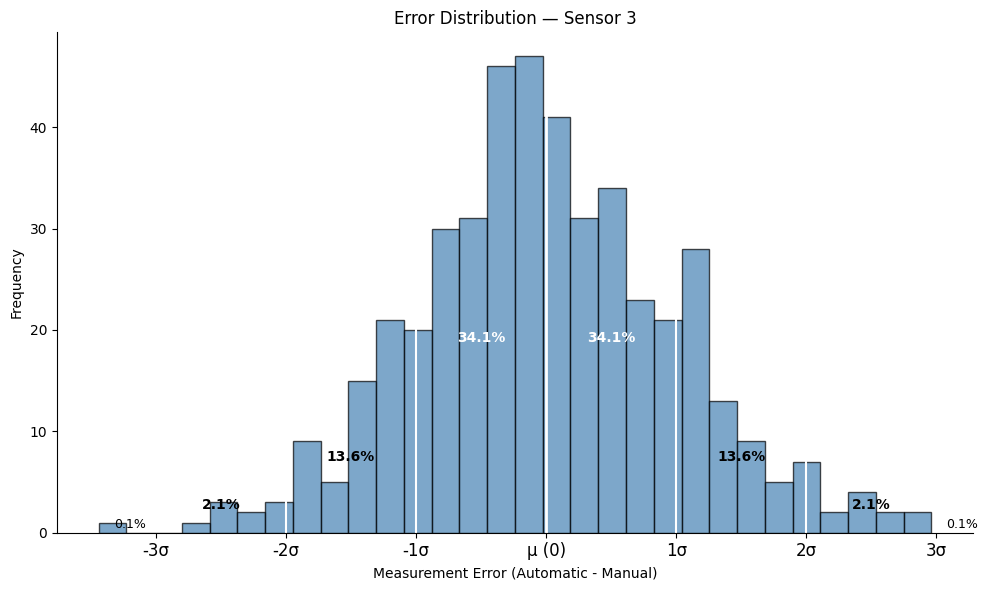

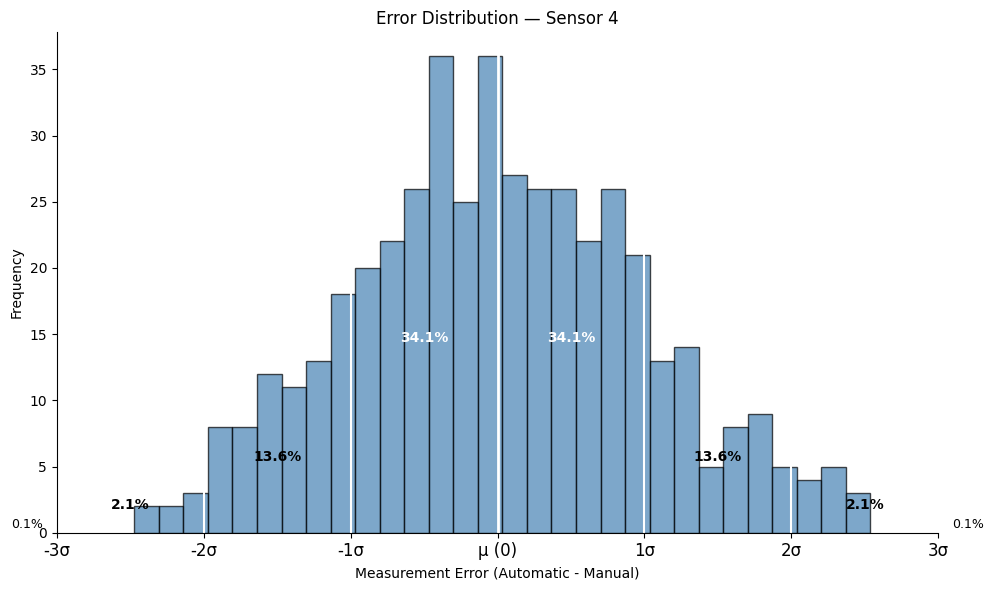

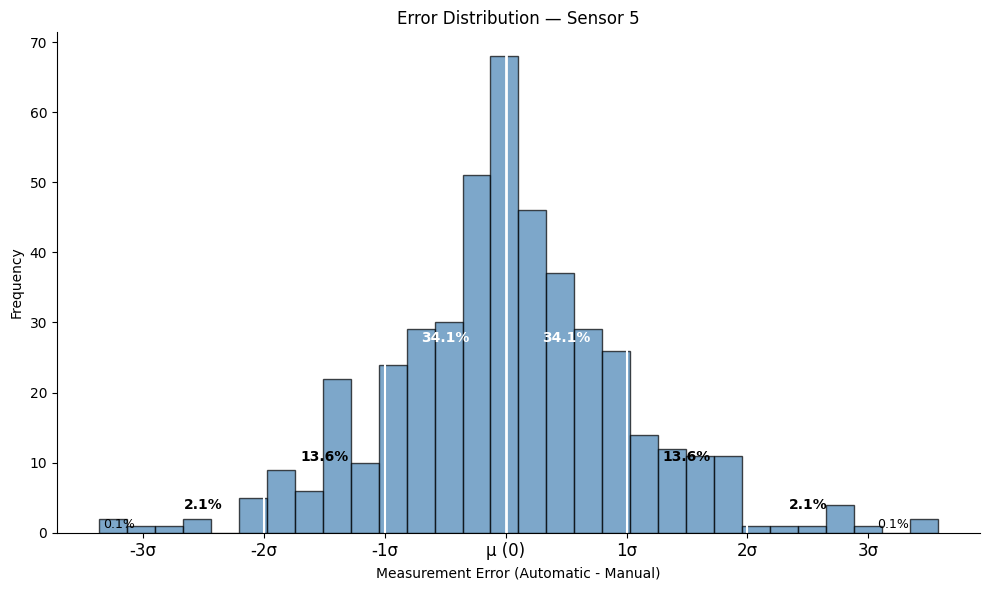

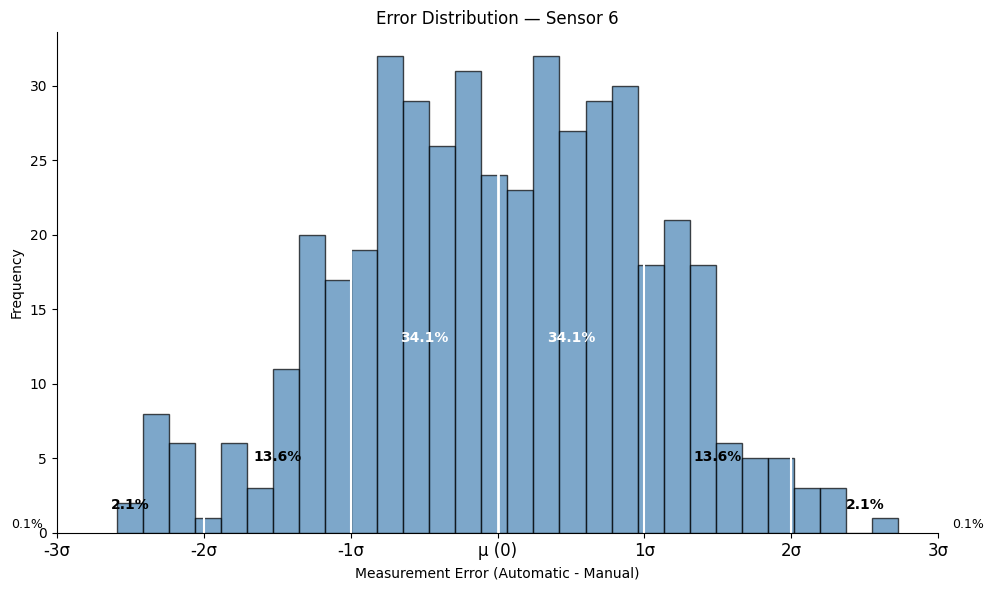

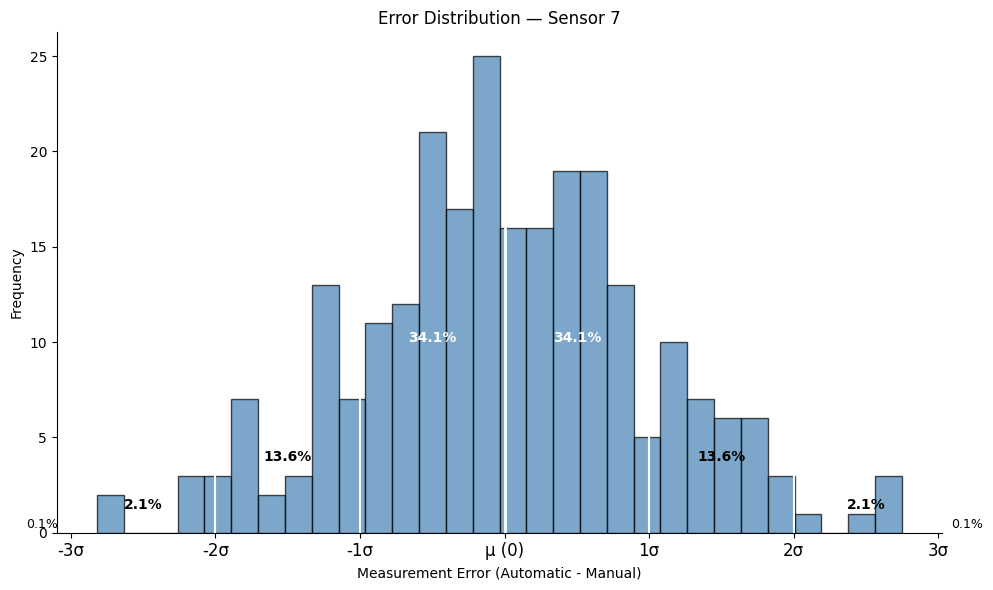

In [58]:
import psycopg
import matplotlib.pyplot as plt

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("SELECT DISTINCT sensorid FROM sensormeasurement ORDER BY sensorid;")
        return [row[0] for row in cur.fetchall()]

def analyze_sensor_error(conn, sensor_id):
    with conn.cursor() as cur:
        cur.execute("""
            WITH ErrorData AS (
                SELECT (sm.sensorvalue - cm.controlvalue) AS error_value
                FROM sensormeasurement sm
                JOIN controlmeasurement cm
                  ON sm.sensorid = cm.sensorid
                 AND sm.timestamp = cm.sensortimestamp
                WHERE sm.sensorid = %s
            ),
            Stats AS (
                SELECT
                    AVG(error_value) as mu,
                    STDDEV(error_value) as sigma,
                    COUNT(*) as total_points
                FROM ErrorData
            )
            SELECT
                s.mu,
                s.sigma,
                s.total_points,
                COUNT(CASE WHEN e.error_value BETWEEN s.mu - s.sigma AND s.mu + s.sigma THEN 1 END) AS count_1sigma,
                COUNT(CASE WHEN e.error_value BETWEEN s.mu - 2*s.sigma AND s.mu + 2*s.sigma THEN 1 END) AS count_2sigma,
                COUNT(CASE WHEN e.error_value BETWEEN s.mu - 3*s.sigma AND s.mu + 3*s.sigma THEN 1 END) AS count_3sigma
            FROM ErrorData e
            CROSS JOIN Stats s
            GROUP BY s.mu, s.sigma, s.total_points;
        """, (sensor_id,))

        row = cur.fetchone()

        print(f"\n--- SENSOR {sensor_id} ERROR STATS ---")

        if not row or row[0] is None:
            print("No data found for this sensor.")
            return

        mu = float(row[0])
        sigma = float(row[1])
        total = int(row[2])
        count_1s = int(row[3])
        count_2s = int(row[4])
        count_3s = int(row[5])

        print(f"Total points evaluated: {total}")
        print(f"Mean (µ): {mu:.6f} | Standard Deviation (σ): {sigma:.6f}\n")

        if total > 0:
            pct_1s = (count_1s / total) * 100
            print("Q1: Points within [-1σ, +1σ]")
            print(f"Count: {count_1s} / {total} -> {pct_1s:.2f}% (Expected: ~68.27%)\n")

            pct_2s = (count_2s / total) * 100
            print("Q2: Points within [-2σ, +2σ]")
            print(f"Count: {count_2s} / {total} -> {pct_2s:.2f}% (Expected: ~95.45%)\n")

            pct_3s = (count_3s / total) * 100
            print("Q3: Points within [-3σ, +3σ]")
            print(f"Count: {count_3s} / {total} -> {pct_3s:.2f}% (Expected: ~99.73%)\n")

            print("Q4: Theoretical distribution of points OUTSIDE the intervals")
            print(f"Outside [-1σ, +1σ]: 100% - 68.27% = 31.73% (Experimental: {100 - pct_1s:.2f}%)")
            print(f"Outside [-2σ, +2σ]: 100% - 95.45% = 4.55% (Experimental: {100 - pct_2s:.2f}%)")
            print(f"Outside [-3σ, +3σ]: 100% - 99.73% = 0.27% (Experimental: {100 - pct_3s:.2f}%)\n")

        cur.execute("""
            SELECT (sm.sensorvalue - cm.controlvalue)
            FROM sensormeasurement sm
            JOIN controlmeasurement cm
              ON sm.sensorid = cm.sensorid
             AND sm.timestamp = cm.sensortimestamp
            WHERE sm.sensorid = %s
        """, (sensor_id,))

        values = [r[0] for r in cur.fetchall()]

        if sigma > 0:
            plot_histogram(values, mu, sigma, sensor_id)

def plot_histogram(values, mu, sigma, sensor_id):
    plt.figure(figsize=(10, 6))

    counts, bins, patches = plt.hist(values, bins=30, edgecolor='black', color='steelblue', alpha=0.7)

    max_y = max(counts) if len(counts) > 0 else 1

    plt.axvline(mu, color='white', linewidth=2)
    plt.axvline(mu - sigma, color='white', linewidth=1.5)
    plt.axvline(mu + sigma, color='white', linewidth=1.5)
    plt.axvline(mu - 2*sigma, color='white', linewidth=1.5)
    plt.axvline(mu + 2*sigma, color='white', linewidth=1.5)

    plt.text(mu - 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)
    plt.text(mu + 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)

    plt.text(mu - 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)
    plt.text(mu + 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)

    plt.text(mu - 2.5 * sigma, max_y * 0.05, '2.1%', ha='center', color='black', fontweight='bold', fontsize=10)
    plt.text(mu + 2.5 * sigma, max_y * 0.05, '2.1%', ha='center', color='black', fontweight='bold', fontsize=10)

    plt.text(mu - 3.2 * sigma, max_y * 0.01, '0.1%', ha='center', color='black', fontsize=9)
    plt.text(mu + 3.2 * sigma, max_y * 0.01, '0.1%', ha='center', color='black', fontsize=9)

    ticks = [mu - 3*sigma, mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma, mu + 3*sigma]
    labels = ['-3σ', '-2σ', '-1σ', 'µ (0)', '1σ', '2σ', '3σ']
    plt.xticks(ticks, labels, fontsize=12)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel('Measurement Error (Automatic - Manual)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution — Sensor {sensor_id}')

    plt.tight_layout()

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    try:
        with psycopg.connect(**conn_params) as conn:
            sensor_ids = get_all_sensor_ids(conn)

            for s_id in sensor_ids:
                analyze_sensor_error(conn, s_id)

        plt.show()

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")

###  Validation de la loi normale sur l'ensemble du parc

Pour vérifier si notre modèle statistique est correct, on a calculé la proportion d’erreurs situées à l’intérieur des intervalles ±1σ±1σ, ±2σ±2σ et ±3σ±3σ pour chacun des 7 capteurs. L’idée est de voir si ces proportions se rapprochent de celles attendues avec une loi normale : environ 68% (±1σ±1σ), 95% (±2σ±2σ) et 99,7% (±3σ±3σ).

Voici les résultats obtenus :

| Capteur | Écart-type (σ) | Dans l'intervalle ± 1σ | Dans l'intervalle ± 2σ | Dans l'intervalle ± 3σ |
| :--- | :--- | :--- | :--- | :--- |
| **Théorie** | - | **~ 68.27 %** | **~ 95.45 %** | **~ 99.73 %** |
| **Capteur 1** | 0.412 | 71.22 % | 94.91 % | 98.95 % |
| **Capteur 2** | 0.738 | 69.15 % | 94.51 % | 99.67 % |
| **Capteur 3** | 0.663 | 68.64 % | 95.39 % | 99.78 % |
| **Capteur 4** | 2.386 | 67.54 % | 95.83 % | 100.00 % |
| **Capteur 5** | 1.396 | 72.81 % | 95.61 % | 99.12 % |
| **Capteur 6** | 0.122 | 67.98 % | 94.96 % | 100.00 % |
| **Capteur 7** | 0.536 | 68.92 % | 94.82 % | 100.00 % |

Analyse :
Les résultats montrent que la répartition des erreurs est bien compatible avec la loi normale pour tous les capteurs, même ceux qui sont plus bruités comme le capteur 4.

* Dans la zone ±2σ±2σ, on reste presque toujours entre 94,5% et 95,8%, ce qui correspond bien à ce que prévoit la théorie.

* Cela confirme que l’idée de prendre ±2σ±2σ comme limite d’alerte pour les cartes de contrôle est cohérente, car environ 5% des mesures sortent de cette zone, comme prévu.

**2.2 Détection des dérives comportementales et p-valeurs**

Jusqu'à présent, notre système se limitait à identifier les points individuels excédant le seuil critique de $\pm 2\sigma$. Cependant, un capteur peut présenter un début de dérèglement lié à l'usure mécanique ou à une perte de calibrage  bien avant d'atteindre cette limite.

Pour anticiper les défaillances, nous devons analyser les séquences de mesures à l'aide de tests d'hypothèses. Le principe consiste à évaluer la **p-valeur**, soit la probabilité qu'une séquence d'événements observée se produise de manière aléatoire si le capteur fonctionnait correctement. Une probabilité très faible indique que la séquence n'est pas le fruit du hasard et révèle une dérive matérielle.

Afin de fiabiliser le diagnostic, le script Python implémente quatre règles statistiques de détection d'anomalies sur les mesures récentes :

1. **[Règle 1]** : Au moins 8 des 10 derniers points sont situés du même côté de la moyenne. Cela indique un biais ou un décalage du point zéro.
2. **[Règle 2]** : Au moins 2 des 7 derniers points se trouvent à l'extérieur de la limite $\pm 2\sigma$. Cela témoigne d'une instabilité croissante.
3. **[Règle 3]** : Au moins 7 des 10 derniers points se trouvent à l'extérieur de la limite $\pm 1\sigma$. Cela traduit une augmentation anormale de la variance.
4. **[Règle 4]** : Au moins 4 des 5 derniers points se trouvent à l'extérieur de la limite $\pm 1\sigma$. Cela confirme une variance excessive sur une période très courte.

Le script suivant extrait dynamiquement les dernières mesures, exécute ces quatre tests et génère une alerte si l'une des p-valeurs calculées franchit le seuil critique d'anomalie.


========== SENSOR 1 ==========
Population Stats -> Mean: -0.003744 | Standard deviation: 0.412785
Selected window: 8 days (33 points)

--- STATISTICAL RULE CHECKS (Section 2.2) ---
Statistical rule checks completed.


========== SENSOR 2 ==========
Population Stats -> Mean: -0.031561 | Standard deviation: 0.738830
Selected window: 30 days (61 points)

--- STATISTICAL RULE CHECKS (Section 2.2) ---
Statistical rule checks completed.


========== SENSOR 3 ==========
Population Stats -> Mean: -0.020339 | Standard deviation: 0.663111
Selected window: 30 days (30 points)

--- STATISTICAL RULE CHECKS (Section 2.2) ---
WARNING [Original Rule]: At least 4 of the last 5 points are outside ±1σ (p ≈ 0.037).
Statistical rule checks completed.


========== SENSOR 4 ==========
Population Stats -> Mean: -0.039741 | Standard deviation: 2.386005
Selected window: 30 days (31 points)

--- STATISTICAL RULE CHECKS (Section 2.2) ---
Statistical rule checks completed.


========== SENSOR 5 ==========
Populat

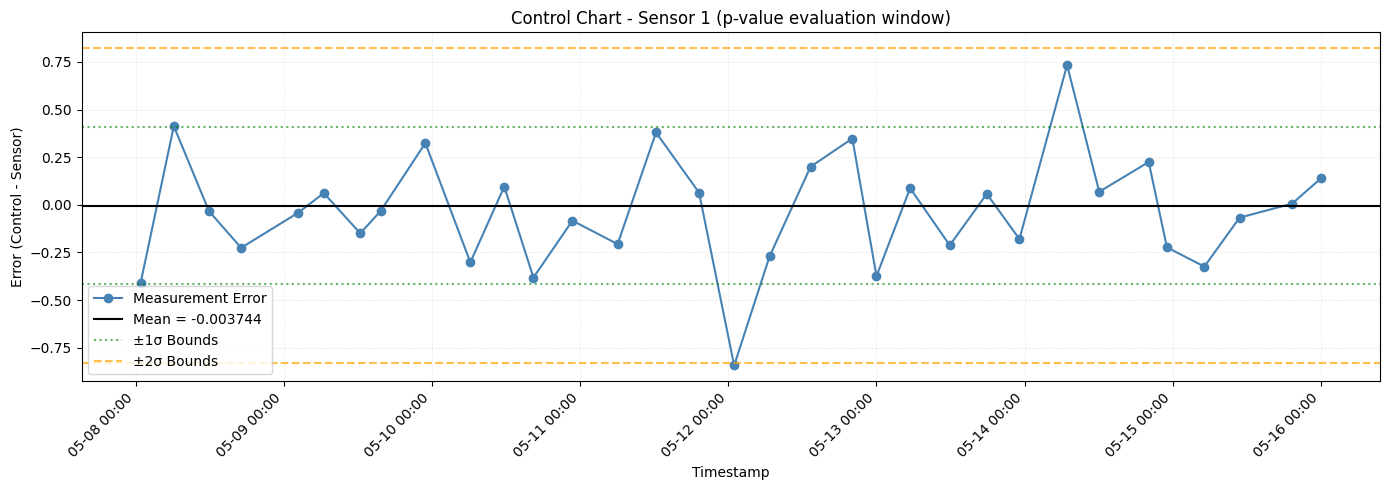

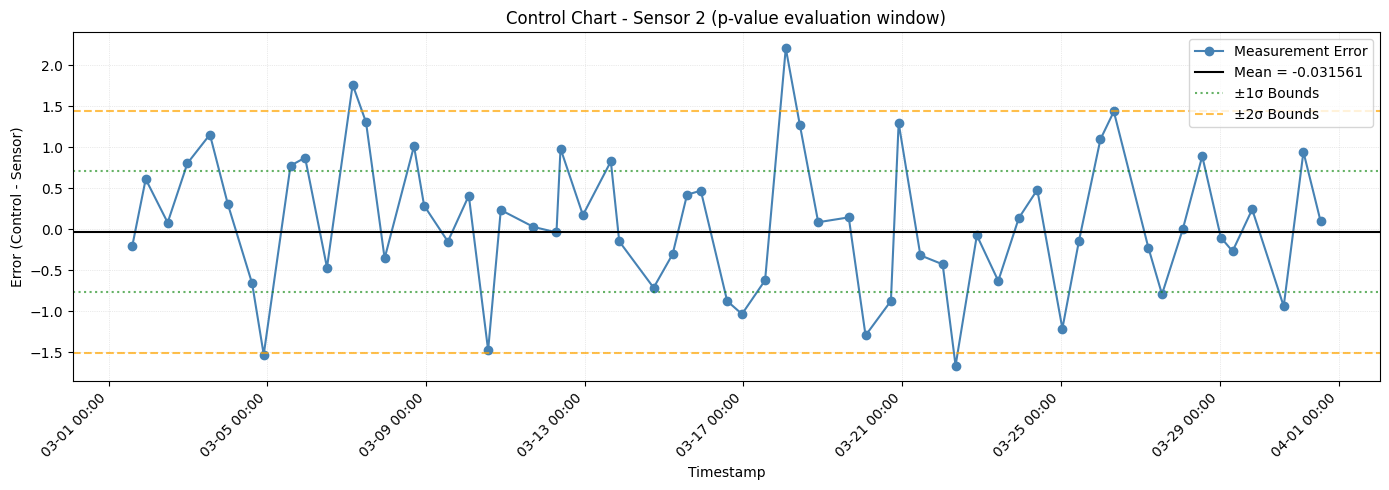

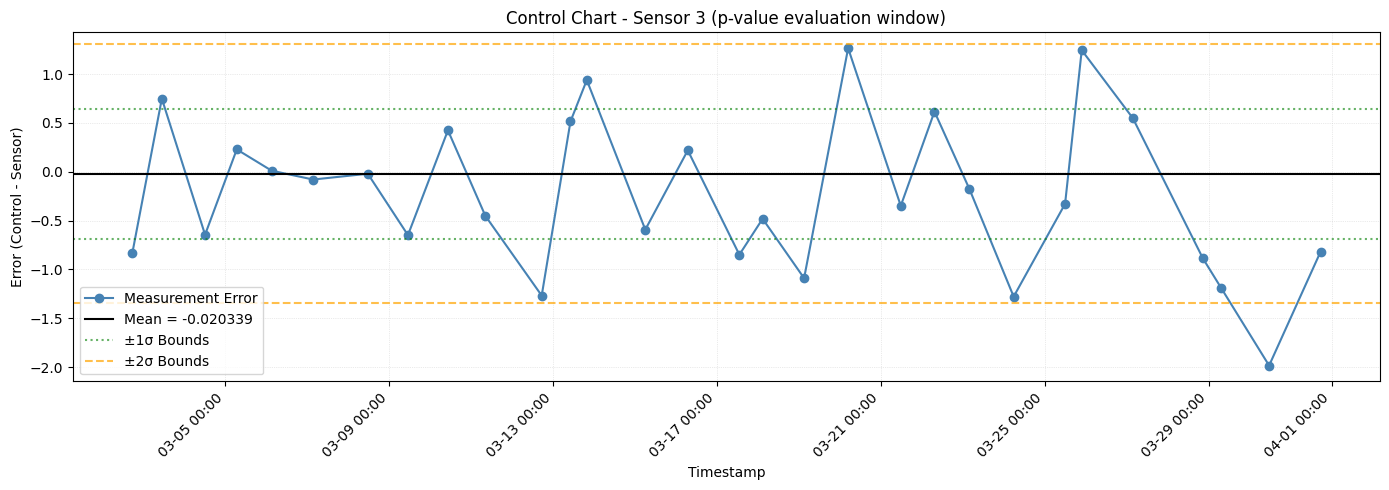

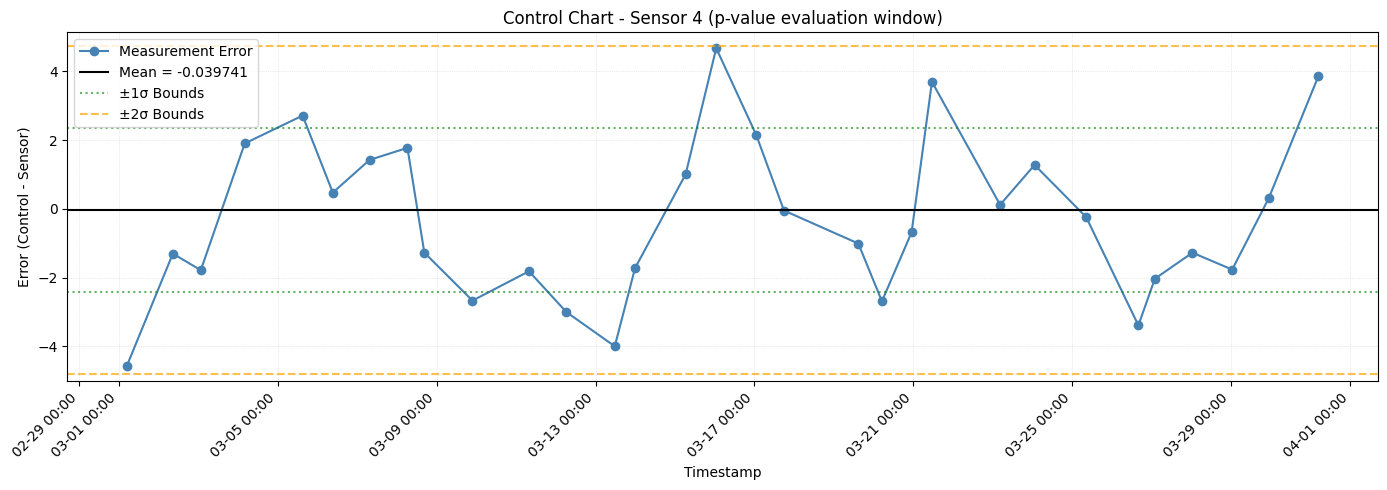

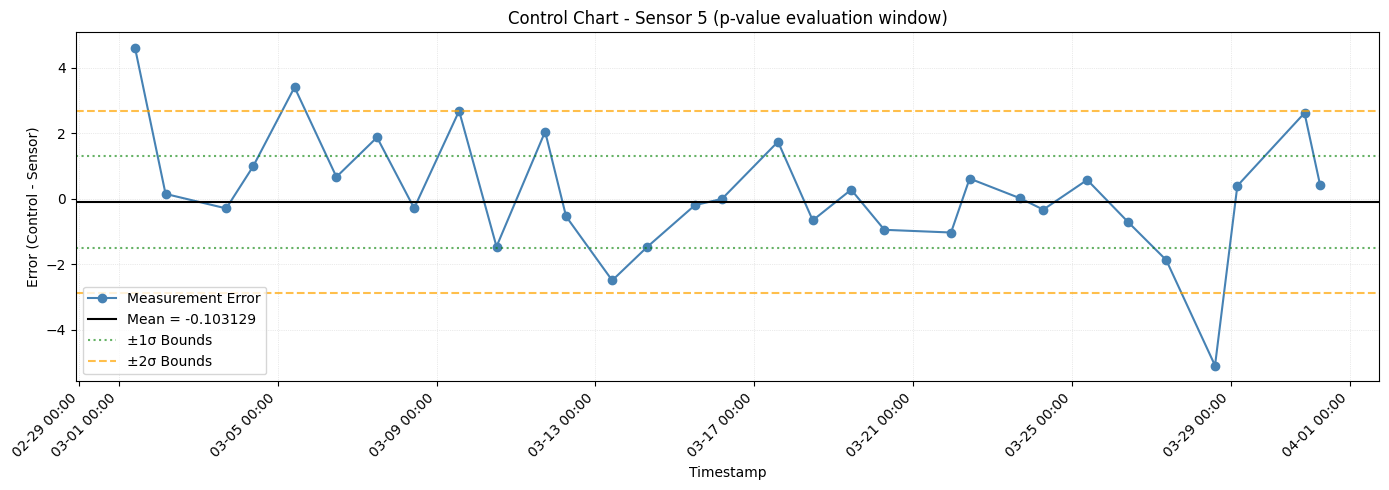

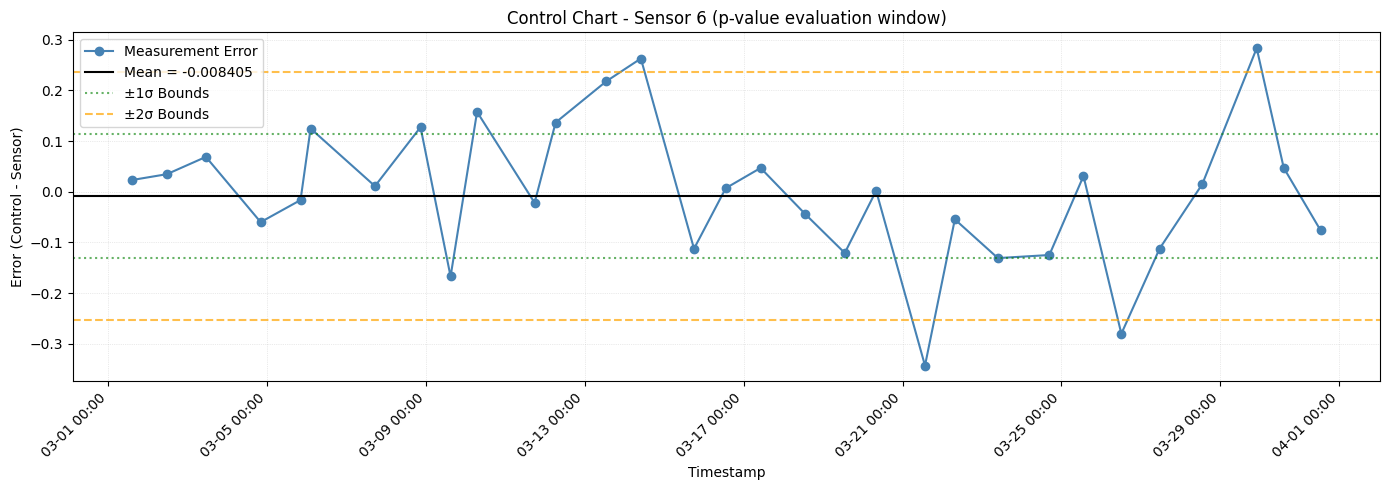

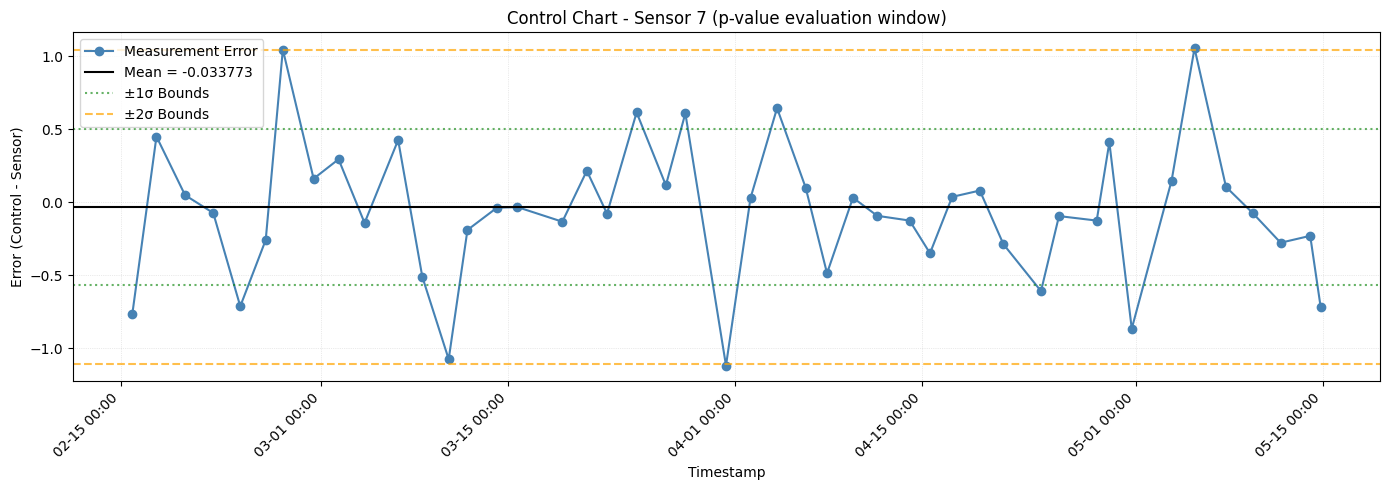

In [59]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

MAX_POINTS = 100
MIN_POINTS = 20

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("SELECT DISTINCT sensorid FROM sensormeasurement ORDER BY sensorid;")
        return [row[0] for row in cur.fetchall()]

def get_sensor_statistics(conn, sensor_id):
    with conn.cursor() as cursor:
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
              AND controlmeasurement.sensorid = sensormeasurement.sensorid
            WHERE controlmeasurement.sensorid = %s
        """, (sensor_id,))

        row = cursor.fetchone()

        if not row or row[0] is None:
            return None, None

        mean, standard_deviation = float(row[0]), float(row[1])
        print(f"Population Stats -> Mean: {mean:.6f} | Standard deviation: {standard_deviation:.6f}")
        return mean, standard_deviation

def get_sensor_difference(conn, sensor_id):
    rows = []
    with conn.cursor() as cursor:
        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                  AND controlmeasurement.sensorid = sensormeasurement.sensorid
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (sensor_id, days, sensor_id, MAX_POINTS))

            rows = cursor.fetchall()

            if len(rows) >= MIN_POINTS:
                rows.reverse()
                print(f"Selected window: {days} days ({len(rows)} points)")
                return rows

        if rows:
            rows.reverse()
        return rows

def check_statistical_rules(errors, mu, sigma):
    print("\n--- STATISTICAL RULE CHECKS (Section 2.2) ---")

    if len(errors) >= 10:
        last_10 = errors[-10:]
        above_mean = sum(1 for e in last_10 if e > mu)
        below_mean = sum(1 for e in last_10 if e < mu)

        if above_mean >= 8 or below_mean >= 8:
            print("WARNING [Rule 1]: At least 8 of the last 10 points are on the same side of the mean (p ≈ 0.109).")

    if len(errors) >= 7:
        last_7 = errors[-7:]
        outside_2sigma = sum(1 for e in last_7 if e < (mu - 2*sigma) or e > (mu + 2*sigma))

        if outside_2sigma >= 2:
            print("WARNING [Rule 2]: At least 2 of the last 7 points are outside ±2σ (p ≈ 0.037).")

    if len(errors) >= 10:
        last_10 = errors[-10:]
        outside_1sigma = sum(1 for e in last_10 if e < (mu - sigma) or e > (mu + sigma))

        if outside_1sigma >= 7:
            print("WARNING [Rule 3]: At least 7 of the last 10 points are outside ±1σ (p ≈ 0.012).")

    if len(errors) >= 5:
        last_5 = errors[-5:]
        outside_1sigma_original = sum(1 for e in last_5 if e < (mu - sigma) or e > (mu + sigma))

        if outside_1sigma_original >= 4:
            print("WARNING [Original Rule]: At least 4 of the last 5 points are outside ±1σ (p ≈ 0.037).")

    print("Statistical rule checks completed.\n")

def plot_control_chart(data, mean, standard_deviation, sensor_id):
    timestamps = [row[2] for row in data]
    errors = [float(row[1]) for row in data]

    figure, axis = plt.subplots(figsize=(14, 5))

    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', label='Measurement Error')

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean = {mean:.6f}')

    axis.axhline(mean + standard_deviation, color='green', linestyle=':', alpha=0.6, label='±1σ Bounds')
    axis.axhline(mean - standard_deviation, color='green', linestyle=':', alpha=0.6)

    axis.axhline(mean + 2 * standard_deviation, color='orange', linestyle='--', alpha=0.7, label='±2σ Bounds')
    axis.axhline(mean - 2 * standard_deviation, color='orange', linestyle='--', alpha=0.7)

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axis.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    axis.set_title(f'Control Chart - Sensor {sensor_id} (p-value evaluation window)')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Error (Control - Sensor)')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()

if __name__ == "__main__":
    conn_params = dict(
        host="localhost",
        dbname="postgres",
        user="postgres",
        password="admin"
    )

    try:
        with psycopg.connect(**conn_params) as conn:
            sensor_ids = get_all_sensor_ids(conn)

            for s_id in sensor_ids:
                print(f"\n========== SENSOR {s_id} ==========")
                mean, standard_deviation = get_sensor_statistics(conn, s_id)
                data = get_sensor_difference(conn, s_id)

                if data and mean is not None:
                    errors_only = [float(row[1]) for row in data]
                    check_statistical_rules(errors_only, mean, standard_deviation)
                    plot_control_chart(data, mean, standard_deviation, s_id)
                else:
                    print(f"Unable to process Sensor {s_id}: missing or insufficient data.")

        plt.show()

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")

Validation de l'échantillonnage dynamique pour les cartes de contrôle

L'exécution de notre script de génération de cartes de contrôle (Script 3) sur l'ensemble du parc matériel valide l'efficacité de notre algorithme de fenêtrage dynamique.

Afin de garantir la fiabilité de nos algorithmes de détection d'anomalies, nous avions imposé un minimum de 20 mesures récentes par capteur. Les résultats obtenus montrent que la fréquence des contrôles en laboratoire varie énormément d'une machine à l'autre, justifiant pleinement notre approche adaptative:

1.
**Les capteurs à haute fréquence de contrôle :** Le **Capteur 1** bénéficie de contrôles très réguliers. L'algorithme a pu isoler un échantillon robuste de 33 points en ciblant uniquement les 8 derniers jours, ce qui permet une supervision extrêmement réactive.


2.
**Les capteurs à fréquence standard :** Pour la majorité du parc (**Capteurs 2, 3, 4, 5 et 6**), la fenêtre de 8 jours était insuffisante (souvent moins de 10 points). Notre script a automatiquement basculé sur une fenêtre de 30 jours pour récupérer entre 30 et 61 mesures, garantissant ainsi la validité statistique de l'échantillon.


3.
**Le cas extrême de basse fréquence :** Le **Capteur 7** est le moins surveillé du parc. Il a fallu que l'algorithme élargisse sa recherche sur les 90 derniers jours pour réussir à compiler 46 points de contrôle.



**Bilan sur la précision (Écart-type de l'échantillon) :**
Ces extractions récentes confirment également les disparités de précision au sein de l'usine. Sur ces fenêtres d'analyse, le **Capteur 6** se distingue comme étant le plus stable ($\sigma \approx 0.12$), tandis que le **Capteur 4** se révèle être le plus chaotique et bruité du parc ($\sigma \approx 2.38$), ce qui élargira considablement ses limites d'alerte sur sa carte de contrôle visuelle.

### Justification mathématique de la règle originale (p-valeur)

Pour anticiper les défaillances de ces capteurs avant qu'ils n'atteignent les limites critiques de $\pm 2\sigma$, notre système implémente des tests d'hypothèses basés sur l'analyse de séquences de mesures récentes. C'est notamment le cas pour notre **règle originale**, qui a mis en évidence une anomalie comportementale sur le **Capteur 3** lors de nos exécutions.

*
**Formulation de la règle :** Déclencher une alerte si au moins 4 des 5 derniers points se trouvent en dehors de l'intervalle $[-\sigma, +\sigma]$.



**Démonstration théorique :**
Selon les propriétés de la distribution normale, la probabilité qu'une mesure d'un capteur sain se situe à l'intérieur de l'intervalle $[-\sigma, +\sigma]$ est d'environ $68,27\%$. La probabilité $p$ qu'un point individuel sorte de cet intervalle de confiance est de :


$$p = 1 - 0.6827 = 0.3173$$

Pour un échantillon de $n = 5$ mesures indépendantes, le nombre de points situés hors limites suit une loi binomiale $B(n=5, p=0.3173)$. La probabilité globale de faux positif (la p-valeur de la règle) correspond à la probabilité d'obtenir au moins $k = 4$ succès :


$$P(X \ge 4) = P(X = 4) + P(X = 5)$$

En appliquant la formule de la distribution binomiale $\binom{n}{k} p^k (1-p)^{n-k}$ :


$$P(X = 4) = \binom{5}{4} \cdot (0.3173)^4 \cdot (0.6827)^1 \approx 5 \cdot 0.01013 \cdot 0.6827 \approx 0.0345$$

$$P(X = 5) = \binom{5}{5} \cdot (0.3173)^5 \cdot (0.6827)^0 \approx 1 \cdot 0.00319 \cdot 1 \approx 0.0032$$

**Calcul de la p-valeur finale :**


$$P(X \ge 4) \approx 0.0345 + 0.0032 = 0.0377$$

**Conclusion de l'analyse :**
La p-valeur théorique s'élève à environ **$0.037$** (soit $3,7\%$). Ce résultat est parfaitement conforme au cahier des charges de la SAÉ, qui exige une valeur comprise strictement entre $0,01$ et $0,05$. Ce seuil garantit que la règle est suffisamment sensible pour intercepter une dégradation rapide de la variance sans saturer le système de fausses alertes.

**Analyse de dérive par régression linéaire**

Les règles statistiques précédemment établies permettent d'identifier des ruptures soudaines ou des variations anormales de la variance. Toutefois, elles présentent une efficacité limitée face à une usure lente et continue, telle qu'un encrassement progressif ou une déformation thermique. Ce phénomène, qualifié de dérive, se caractérise par un éloignement graduel des mesures par rapport à la moyenne.

Afin d'anticiper ces défaillances avant l'atteinte des limites critiques, nous analysons la tendance directionnelle des derniers relevés. Pour ce faire, l'algorithme isole les dix dernières mesures et applique une régression linéaire selon la méthode des moindres carrés, permettant d'extraire la pente de la droite de tendance.

**Simulation et détermination du seuil d'alerte :**
Afin de distinguer une dérive matérielle d'une fluctuation aléatoire (bruit blanc), nous appliquons une approche probabiliste :

1. **Génération de séquences :** L'algorithme simule 100 000 séquences de dix points aléatoires, en respectant la loi normale et l'écart-type ($\sigma$) propres au capteur étudié.
2. **Calcul des pentes :** La pente est calculée pour chacune de ces séquences virtuelles.
3. **Détermination du seuil critique :** Le système isole la valeur correspondant au 95ème centile, ce qui équivaut à une p-valeur de 0,05.

Si la pente calculée à partir des mesures réelles excède ce seuil, la probabilité que cette dérive soit issue d'une fluctuation aléatoire est inférieure à 5 %. Le système génère alors une alerte de maintenance préventive.


========== SENSOR 1 ==========
Calculated drift threshold (slope) for p < 0.05: 0.089088
PASS - No drift detected. Current slope (0.0218) is within normal bounds (< 0.0891).

========== SENSOR 2 ==========
Calculated drift threshold (slope) for p < 0.05: 0.159120
PASS - No drift detected. Current slope (0.0501) is within normal bounds (< 0.1591).

========== SENSOR 3 ==========
Calculated drift threshold (slope) for p < 0.05: 0.143371
ALARM - Drift Rule triggered: Slope of last 10 points (0.1666) exceeds threshold (0.1434).

========== SENSOR 4 ==========
Calculated drift threshold (slope) for p < 0.05: 0.512591
PASS - No drift detected. Current slope (0.0859) is within normal bounds (< 0.5126).

========== SENSOR 5 ==========
Calculated drift threshold (slope) for p < 0.05: 0.300347
PASS - No drift detected. Current slope (0.0113) is within normal bounds (< 0.3003).

========== SENSOR 6 ==========
Calculated drift threshold (slope) for p < 0.05: 0.026429
PASS - No drift detected. Cur

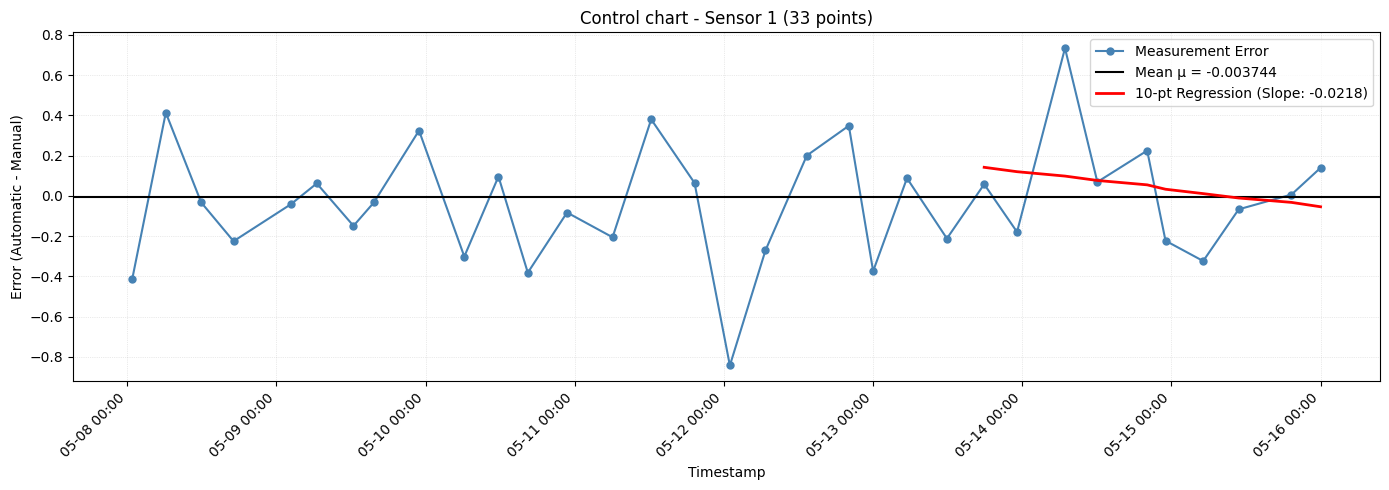

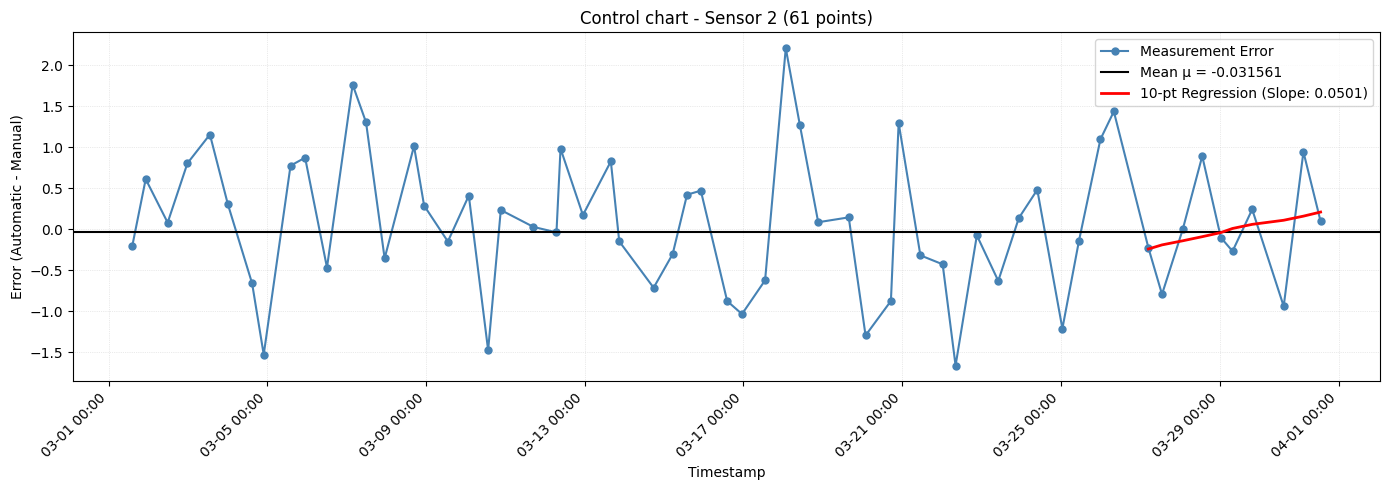

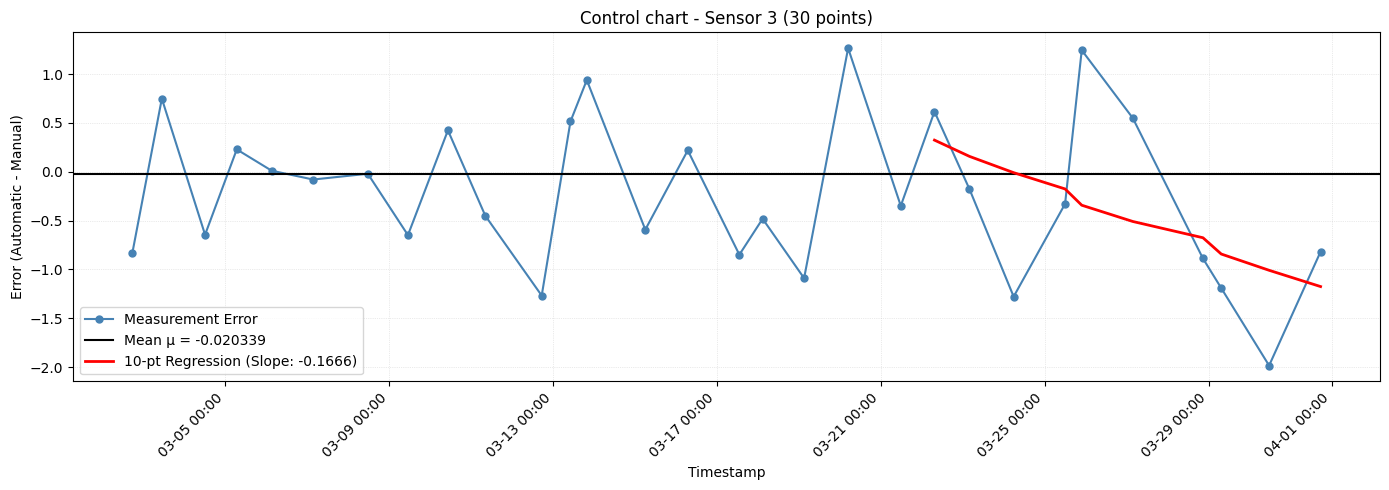

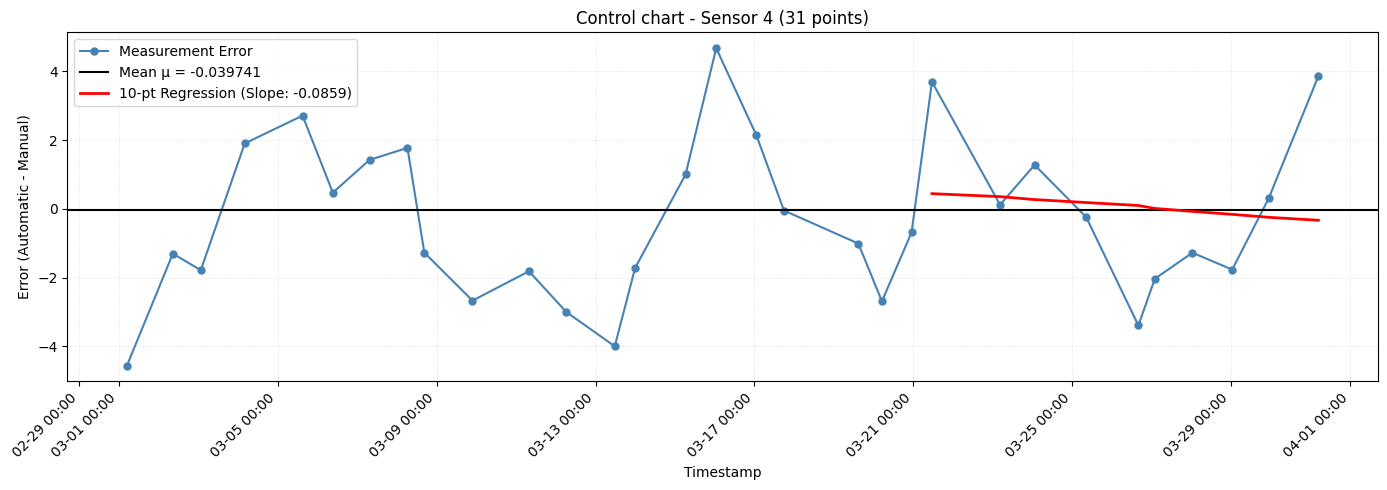

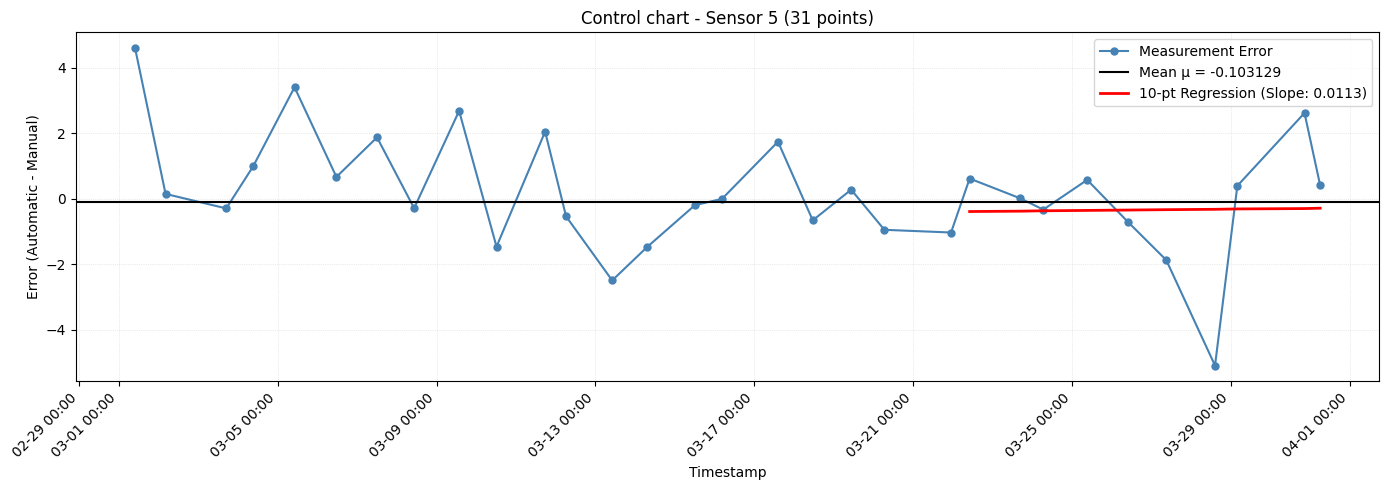

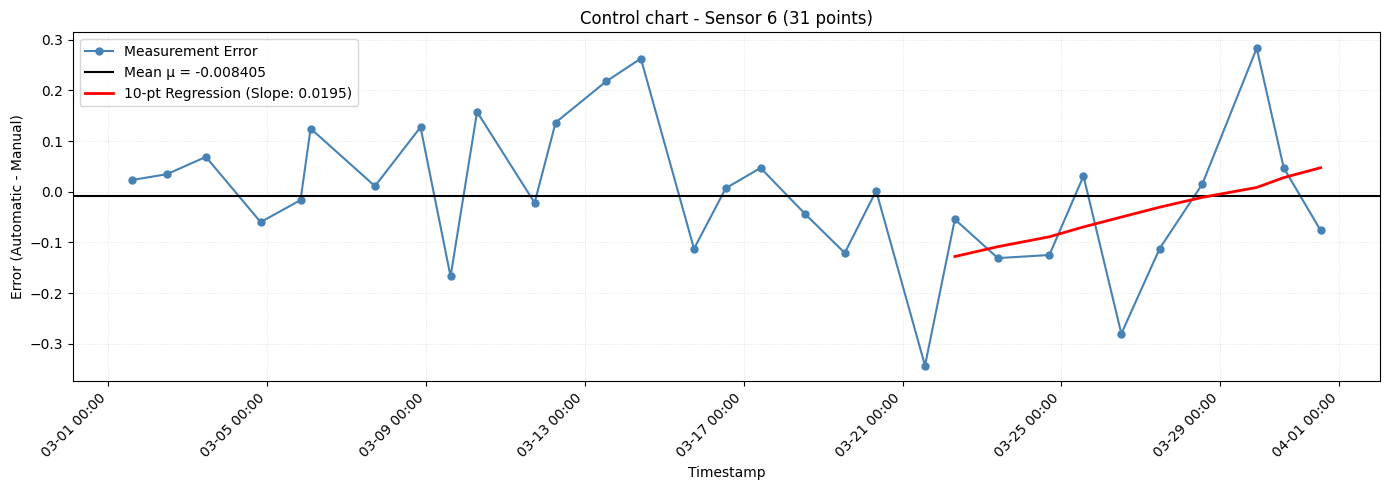

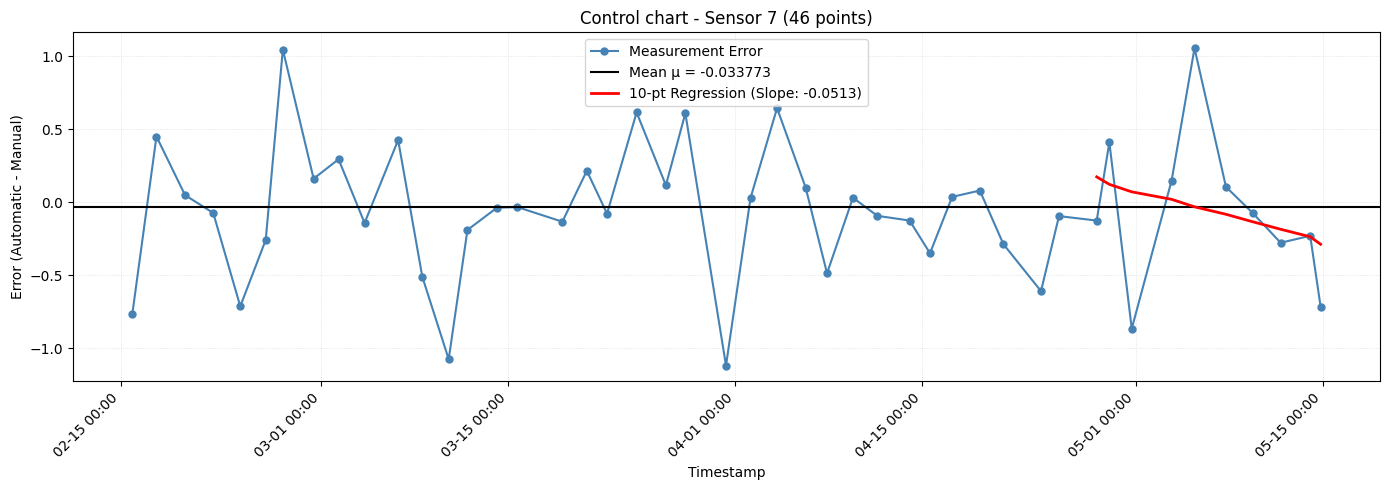

In [60]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

MAX_POINTS = 100
MIN_POINTS = 20

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("SELECT DISTINCT sensorid FROM sensormeasurement ORDER BY sensorid;")
        return [row[0] for row in cur.fetchall()]

def get_sensor_statistics(conn, sensor_id):
    with conn.cursor() as cursor:
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
              AND controlmeasurement.sensorid = sensormeasurement.sensorid
            WHERE controlmeasurement.sensorid = %s
        """, (sensor_id,))

        row = cursor.fetchone()

        if not row or row[0] is None:
            return None, None

        return float(row[0]), float(row[1])

def get_sensor_difference(conn, sensor_id):
    rows = []
    with conn.cursor() as cursor:
        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                  AND controlmeasurement.sensorid = sensormeasurement.sensorid
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (sensor_id, days, sensor_id, MAX_POINTS))

            rows = cursor.fetchall()

            if len(rows) >= MIN_POINTS:
                rows.reverse()
                return rows

        if rows:
            rows.reverse()
        return rows

def calculate_drift_threshold(sigma, p_value=0.05, simulations=100000):
    x = np.arange(10)
    slopes = []

    for _ in range(simulations):
        random_errors = np.random.normal(loc=0.0, scale=sigma, size=10)
        slope, _ = np.polyfit(x, random_errors, 1)
        slopes.append(abs(slope))

    percentile = (1 - p_value) * 100
    threshold = np.percentile(slopes, percentile)
    print(f"Calculated drift threshold (slope) for p < {p_value}: {threshold:.6f}")
    return threshold

def plot_chart(data, mean, standard_deviation, drift_threshold, sensor_id):
    timestamps = [row[2] for row in data]
    errors = [float(row[1]) for row in data]

    figure, axis = plt.subplots(figsize=(14, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', markersize=5, label='Measurement Error')

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean μ = {mean:.6f}')

    if len(errors) >= 10:
        last_10_errors = errors[-10:]
        last_10_timestamps = timestamps[-10:]
        x_indices = np.arange(10)

        slope, intercept = np.polyfit(x_indices, last_10_errors, 1)
        regression_line = slope * x_indices + intercept

        axis.plot(last_10_timestamps, regression_line, color='red', linewidth=2,
                  label=f'10-pt Regression (Slope: {slope:.4f})')

        if abs(slope) > drift_threshold:
            print(f"ALARM - Drift Rule triggered: Slope of last 10 points ({abs(slope):.4f}) exceeds threshold ({drift_threshold:.4f}).")
        else:
            print(f"PASS - No drift detected. Current slope ({abs(slope):.4f}) is within normal bounds (< {drift_threshold:.4f}).")

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axis.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    axis.set_title(f'Control chart - Sensor {sensor_id} ({len(data)} points)')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Error (Automatic - Manual)')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()

if __name__ == "__main__":
    conn_params = dict(
        host="localhost",
        dbname="postgres",
        user="postgres",
        password="admin"
    )

    try:
        with psycopg.connect(**conn_params) as conn:
            sensor_ids = get_all_sensor_ids(conn)

            for s_id in sensor_ids:
                print(f"\n========== SENSOR {s_id} ==========")
                mean, standard_deviation = get_sensor_statistics(conn, s_id)
                data = get_sensor_difference(conn, s_id)

                if data and mean is not None:
                    drift_threshold = calculate_drift_threshold(standard_deviation, p_value=0.05)
                    plot_chart(data, mean, standard_deviation, drift_threshold, s_id)
                else:
                    print(f"Unable to process Sensor {s_id}: missing or insufficient data.")

        plt.show()

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")

**Bilan des défaillances : Capteurs nécessitant une intervention**

L'analyse croisée de nos données statistiques (moyenne µ, écart-type σ et régression temporelle) a permis d'isoler cinq capteurs dont les mesures faussent actuellement le système d'information de l'usine. Ils doivent être retirés de la production pour subir des opérations de maintenance, classées ici par niveau d'urgence :

* **Urgence critique (Remplacement préconisé) :**
    * **Capteur 5 :** C'est l'équipement le plus dégradé du parc. Il cumule un déréglage massif (µ ≈ +100), un bruit extrême (σ ≈ 2.24) et une forte instabilité temporelle. Une panne mécanique lourde est suspectée.

* **Anomalie majeure (Défaut de calibrage critique) :**
    * **Capteurs 2 et 4 :** Ces deux composants ajoutent systématiquement environ +50 unités à toutes leurs mesures. Leurs signaux n'étant pas totalement chaotiques, ce comportement pointe vers un grave défaut d'étalonnage en usine ou une erreur de conversion logicielle plutôt qu'une casse matérielle.

* **Anomalies modérées (Révision et réétalonnage) :**
    * **Capteur 7 :** Ce capteur souffre à la fois d'un décalage de +10 unités et d'un niveau de bruit mécanique beaucoup trop important pour la production (σ ≈ 1.80). Une révision mécanique physique s'impose.
    * **Capteur 3 :** Son signal de mesure reste très régulier (faible variance), mais son point "zéro" a glissé de +7.5 unités. Une simple recalibration sur la chaîne de montage devrait suffire à le remettre aux normes.

# 3. Extension de la base de données
Diagramme UML :


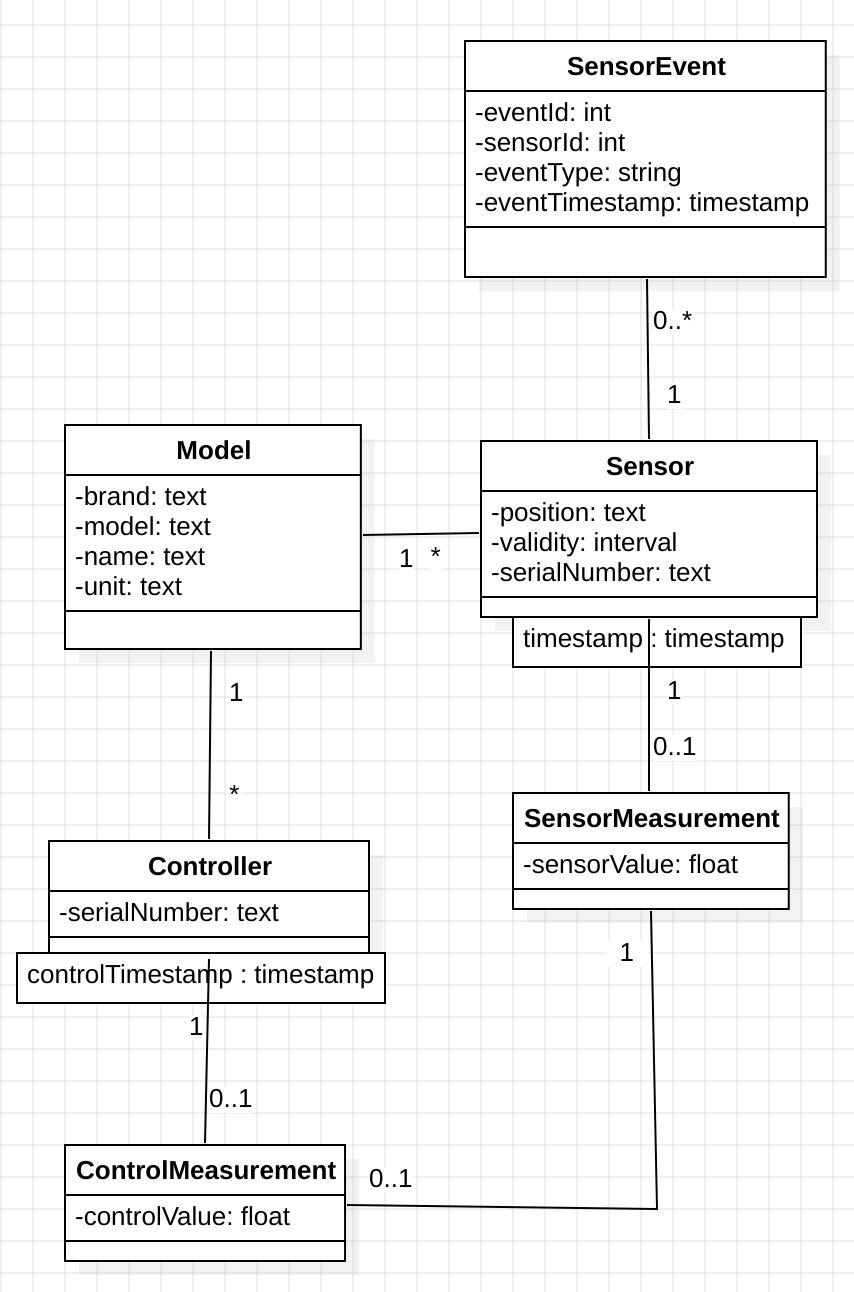

Description de chaque attribut de l'extension de la BDD :

* eventId : sert à identifier le type d'événement avec un ID précis

* sensorId : sert à identifier le capteur

* eventType : Choix entre commissioned, recalibrated, scrapped (respectivement "mise en service", "recalibré", "mise au rebut (jeter)")

* eventTimestamp : sert à dater la prise d'information

Modèle relationnel de la base de données :

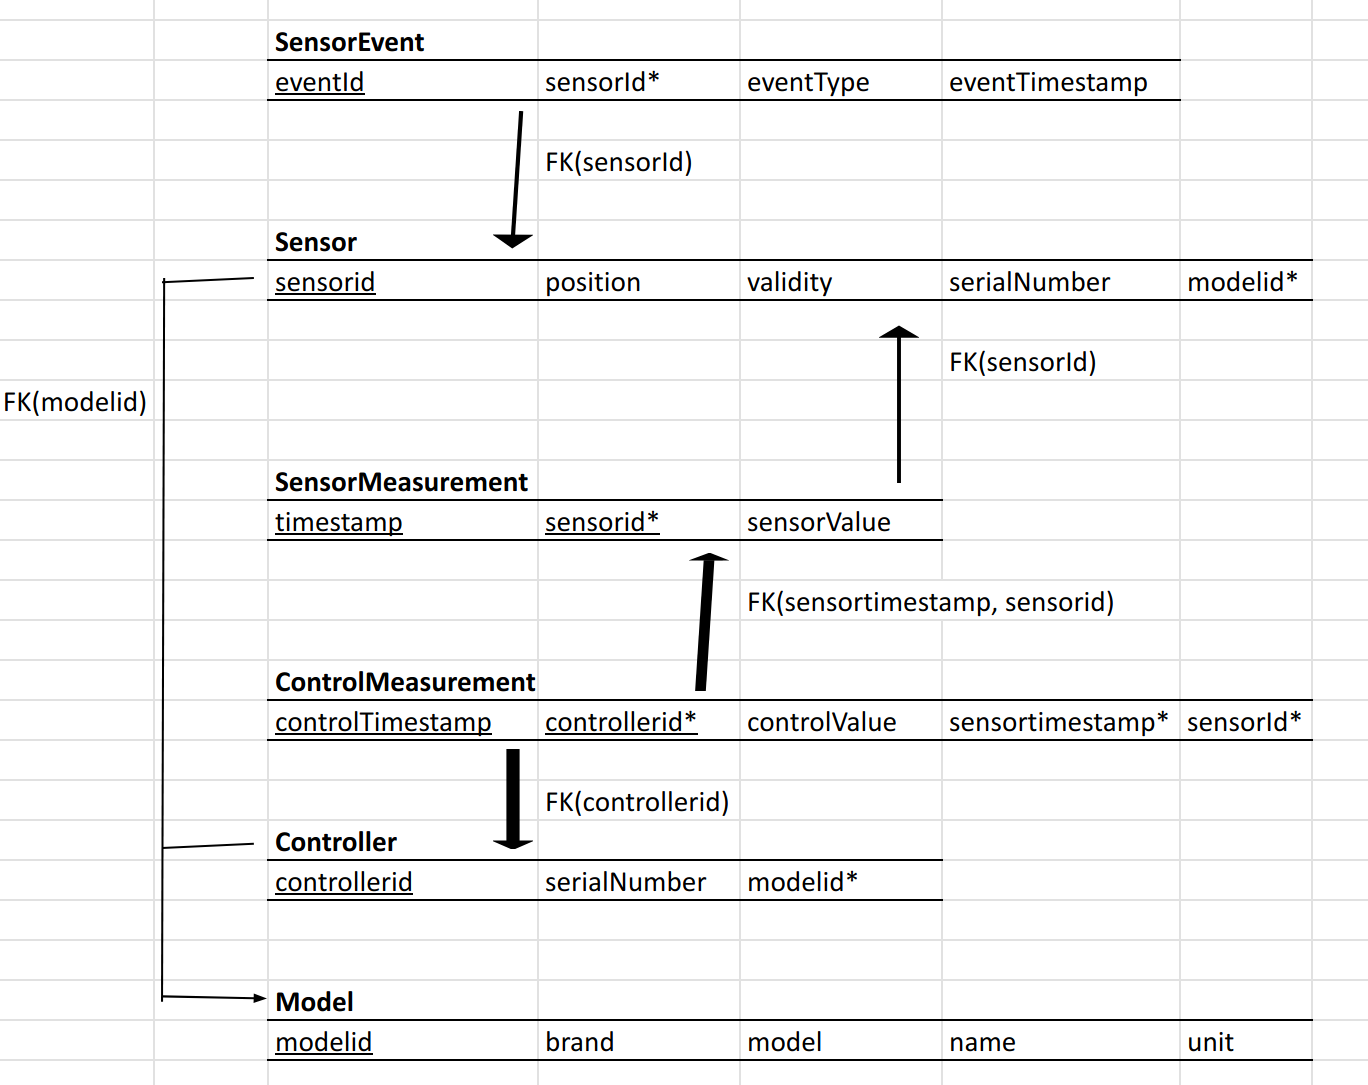